<a href="https://colab.research.google.com/github/alecksandr26/Argus/blob/main/notebook/ArgusMLModel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Argus — RandomForest Model and Dataset Definition

**Project:** System for detecting drowsiness in truck drivers and providing preventive assistance.

**Objective:** Define a reproducible pipeline that converts raw `.mp4` recordings into a
structured `.csv` dataset, used to train the Argus `LSTM` (recurrent neural network) to predict
a driver's drowsiness level.

**Solution:** After evaluating several architectures, we chose an `LSTM` because it is
lightweight, easy to implement, and fits our pipeline well: a pretrained `CNN-based` model
(`MediaPipe FaceLandmarker`) extracts facial landmarks, blendshape scores, and head pose per
frame; these are preprocessed into a set of interpretable ratios and scores (see below), which
become the time-series input to the `LSTM` that predicts the drowsiness level.



## Drowsiness levels (labels)



| Level | Description |
|---|---|
| 1 | Alert, fully awake |
| 2 | Alert, slightly relaxed |
| 3 | Mild signs of tiredness |
| 4 | Tired |
| 5 | Very tired / sleepy |
| 6 | Entering microsleep |

## Feature extraction from facial landmarks



We use MediaPipe's pretrained `FaceLandmarker` model, which internally runs a face detector,
a face mesh model, and a blendshape prediction model to output, per frame:

- 478 3D facial landmarks (x, y, z)
- 52 ARKit-style blendshape scores (0–1), pre-normalized for pose and scale
- A 4×4 head-pose transformation matrix

Rather than feeding raw landmark coordinates directly into the LSTM (noisy, pose- and
scale-dependent, and very high-dimensional), we derive a curated set of interpretable features
from these outputs:



1. **Manual EAR / MAR** (`output_face_landmarks`): Eye Aspect Ratio and Mouth Aspect Ratio,
   computed directly from the 2D landmark coordinates using the standard six-point (eyes) and
   four-point (mouth) formulas. We keep these even though blendshapes cover similar ground,
   because they are simple, fully interpretable, and give us an independent baseline to compare
   against the blendshape-based features during the statistical validation step.
2. **Face blendshapes** (`output_face_blendshapes=True`): 52 ARKit-style coefficients
   (`eyeBlinkLeft`, `eyeBlinkRight`, `eyeSquintLeft/Right`, `jawOpen`, `browDownLeft/Right`,
   `mouthClose`, etc.), already normalized by MediaPipe's model for head pose and face scale —
   effectively pre-computed facial action units, and generally less noisy than EAR/MAR when the
   driver's head is turned.
3. **Head pose** (`output_facial_transformation_matrixes=True`): a 4×4 transformation matrix
   from which we extract pitch, yaw, and roll directly. Head nodding is a strong signal of
   microsleep, and is not captured by the blendshapes above.

### Candidate per-frame features


The table below lists every per-frame feature we currently extract as a candidate for the LSTM
input sequence, along with the rationale for including it.

| Category | Feature(s) | Source | Rationale |
|---|---|---|---|
| Eyes (manual EAR) | `EAR_left`, `EAR_right` | 2D landmarks, computed manually | Kept for interpretability and as a comparison baseline, even though it is pose-sensitive |
| Eyes (blendshape) | `eyeBlinkLeft`, `eyeBlinkRight` | Blendshape | Pose-robust equivalent of the same phenomenon captured by EAR |
| Eyes (blendshape) | `eyeSquintLeft`, `eyeSquintRight` | Blendshape | Squinting associated with visual fatigue |
| Eyes (blendshape) | `eyeWideLeft`, `eyeWideRight` | Blendshape | Widening of the eyes as a conscious effort to stay awake (sometimes precedes a lapse) |
| Gaze | `eyeLookDownLeft`, `eyeLookDownRight` | Blendshape | Gaze drifting downward together with the head |
| Mouth (manual MAR) | `MAR` | 2D landmarks, computed manually | Kept for interpretability, same rationale as EAR |
| Mouth / jaw (blendshape) | `jawOpen`, `mouthFunnel`, `mouthStretchLeft`, `mouthStretchRight` | Blendshape | Yawning — **note the speech/singing confound**, see below |
| Mouth (blendshape) | `mouthClose`, `mouthPressLeft`, `mouthPressRight` | Blendshape | Loss of muscle tone around the mouth at rest |
| Eyebrows (blendshape) | `browDownLeft`, `browDownRight`, `browInnerUp` | Blendshape | Conscious effort to stay alert |
| Speech confound flag | `mouthSmileLeft`, `mouthSmileRight`, short-window mouth variance | Blendshape | Auxiliary signal to help detect whether the driver is talking or singing, so it is not mistaken for yawning — relevant since truck drivers frequently talk on the radio/phone or sing |
| Head pose | `pitch`, `yaw`, `roll` | Facial transformation matrix (not a blendshape) | Head nodding is a strong signal of microsleep |
| Sample quality | `detection_confidence`, `frame_has_face` (0/1) | Detector metadata | Used to discard or down-weight low-confidence frames |



### How we will validate which features actually matter




Rather than assuming all of the above are equally useful, we will validate each feature's
relevance statistically once the aggregated per-clip dataset is built (see the next section):

1. **Shapiro-Wilk test** on each aggregated feature, to check for normality and decide between
   parametric and non-parametric tests.
2. **Kruskal-Wallis test** comparing each feature's distribution across drowsiness levels
   (non-parametric, since the data is expected to be non-normal) — a low p-value indicates the
   feature meaningfully discriminates between levels.
3. **Spearman correlation** between each feature and the drowsiness level, since the label is
   ordinal rather than continuous-linear.
4. **Linear mixed-effects model**, with drowsiness level as a fixed effect and subject as a
   random effect, to control for repeated measurements from the same person.
5. **Pairwise Spearman correlation matrix between features**, to detect redundancy (e.g. if
   `EAR_left` and `eyeBlinkLeft` are highly correlated, only one may be needed in the final
   input set).

Features that show no significant relationship with drowsiness level in this analysis are
candidates for removal before finalizing the LSTM input set.

### Bridging to Pandas Analysis & Real-Time Streaming Strategy (`.npy` + `metadata.csv`)

To balance thorough statistical feature analysis with real-time inference constraints (<2s recovery),
we adopt a binary storage and index-pointer strategy:

* Why individual binary files (`.npy`)? Video clips vary in duration and frame rate (e.g., `24` vs. `30` fps).
  Storing each clip as a native NumPy matrix `[num_frames, num_features]` preserves variable-length
  sequences naturally without forcing rigid padding during exploratory analysis.
  
* Why a lightweight `metadata.csv`? The master CSV maps each clip to its subject ID and drowsiness level,
  allowing us to run Pandas-based statistical tests (`Kruskal-Wallis`, `Spearman correlation`) and
  subject-wise Group `K-Fold` splits safely before model training.
  
* Real-Time & Crash Recovery Architecture: For deployment, the model does not wait for full clips.
  It utilizes a rolling `1–2` second sliding window (`30–60` frames). If a system crash occurs, re-feeding
  just the latest 1 second of frames instantly warms up the LSTM hidden state, guaranteeing a prediction
  latency well under ~1 second.

# Project Structure & Feature Extraction Strategy



To balance thorough statistical feature analysis with real-time inference constraints, we adopt a sliding window strategy:

* **Sampling Rate:** Videos are processed at a fixed **10 FPS** (`sampling_fps = 10`) to match the expected performance of target hardware.
* **Sliding Window Architecture:** Instead of processing whole clips, we generate dynamic sequences with durations of **1.0, 2.0, 3.0, 4.0, 5.0, and 6.0 seconds**. These windows slide across each video with a **1-second stride**.
* **Data Integrity & Filtering:** If a face is lost in a frame, a dummy vector is recorded. To ensure the LSTM only trains on continuous, high-quality data, **any window containing even one invalid frame is discarded**.
* **Output Artifacts:** Each valid window is saved as an individual `.npy` file, and a master `metadata.csv` tracks the subject, drowsiness level, window duration, and the total count of dropped frames per parent video.

Here is the complete project folder layout for Argus. It is designed to keep everything organized in Google Drive: models/ stores our core assets and trained weights, dataset/raw_videos/ holds our source recordings organized by subject, and dataset_processed/ houses our extracted .npy time-series files and metadata.csv (which can also be packaged into a .zip file for easy backups or portability).


```Text
/content/drive/MyDrive/Argus/
├── models/                    <- Stores our pretrained MediaPipe task & final trained LSTM model weights
├── dataset/
│   └── raw_videos/            <- Organized by subject folders with level-labeled video clips
│       ├── subject_01/
│       │   ├── level_1_clip_01.mp4
│       │   ├── level_1_clip_02.mp4
│       │   ├── level_3_clip_01.mp4
│       │   └── ...
│       ├── subject_02/
│       │   └── ...
│       └── ...
└── dataset_processed/
    ├── features/              <- .npy time-series feature matrices generated per clip
    └── metadata.csv           <- Master index table for Pandas analysis & LSTM training
```
**Key Folder Breakdown**

*    `models/`: Dedicated home for all model files—housing both the pretrained
* `dataset/raw_videos/`: The raw input directory structured cleanly by subject ID (e.g., `subject_01/`, `subject_02/`), containing the original .mp4 video clips.

*    `dataset_processed/`: Holds the structured outputs (`features/` and `metadata.csv`). This entire folder can be compressed into a `.zip` archive whenever you need a fast backup or want to move your processed dataset across different machine learning environments.

## Google Drive Connection

We mount Google Drive to seamlessly save and load our project files (pretrained models, raw video datasets, and processed artifacts) directly in the cloud, ensuring that all our work persists safely across Google Colab session disconnects.

In [1]:
from google.colab import drive
import os

# Mount Google Drive in the Colab environment
drive.mount('/content/drive')

# Define the base root path for the Argus project
project_folder = "/content/drive/MyDrive/Argus"

print(f"Google Drive successfully mounted! Base project directory: {project_folder}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive successfully mounted! Base project directory: /content/drive/MyDrive/Argus


## Project Directory Setup & Validation
Firstly, validate and initialize the project root folder.

In [2]:
import os

if not os.path.exists(project_folder):
    raise Exception(f"The target directory could not be initialized: '{project_folder}'.")

Then, validate and create the necessary project folders to ensure they exist.


In [3]:
import os

# Define the subpaths for the Argus project structure
models_folder = f"{project_folder}/models"
dataset_folder = f"{project_folder}/dataset"
raw_videos_folder = f"{dataset_folder}/raw_videos"
processed_folder = f"{dataset_folder}/dataset_processed"
features_folder = f"{processed_folder}/features"

if not os.path.exists(raw_videos_folder):
  raise Exception(f"The target directory could not be initialized: '{raw_videos_folder}'.")

# List of all directories that need initialize
folders_to_create = [
    models_folder,
    processed_folder,
    features_folder
]

# Create directories if they do not exist
for folder in folders_to_create:
    os.makedirs(folder, exist_ok=True)

print("Project folder structure successfully created and verified.")

Project folder structure successfully created and verified.


Finally, check for uploaded subject directories. If no subjects exist, issue a warning to ensure data is present before proceeding.


In [4]:
import glob

# Validation check: Ensure raw_videos folder contains video clips
# Search recursively for any .mp4 files within the subject folders
video_files = glob.glob(os.path.join(raw_videos_folder, "**/*.mp4"), recursive=True)
if len(video_files) == 0:
    raise Exception(f"No video clips found in the specified directory: '{raw_videos_folder}'.")
print(f"[SUCCESS] Raw video directory validated: Found {len(video_files)} clip(s) ready for processing.")

[SUCCESS] Raw video directory validated: Found 27 clip(s) ready for processing.


# Raw Video Dataset Exploratory Visualization / Histogram


This cell processes your raw video files to extract metadata, calculate exact video lengths, and organize them by subjects and drowsiness levels. Here is a breakdown of what the code does step-by-step:

* **Subject Mapping:**
  * Loops through all discovered `.mp4` paths and extracts the immediate parent folder name (e.g., `subject_01`) to track data ownership per person.
* **Duration Calculation (OpenCV):**
  * Opens each video to read its frames-per-second (`FPS`) and total frame count.
  * Divides total frames by FPS to get the exact clip duration in seconds, then accumulates it toward both the subject and the drowsiness level totals.
* **Level Parsing (Regex):**
  * Uses a regular expression pattern (`level_(\d+)`) to pull the drowsiness level integer from the filename. Unrecognized filenames are logged with a `-1` flag.
* **Summary Compilation:**
  * Aggregates final counts using `Counter` and prints a status message reporting total clips and subjects processed.

In [5]:
import re
from collections import Counter
import cv2

if not video_files:
    raise Exception(f"No video clips found in '{raw_videos_folder}' to analyze. Please check your path or uploads.")

levels = []
subjects = []
level_durations = Counter()
subject_durations = Counter()

for file_path in video_files:
    filename = os.path.basename(file_path)

    # Extract subject ID from the parent directory name (e.g., subject_01)
    parent_dir = os.path.basename(os.path.dirname(file_path))
    subjects.append(parent_dir)

    # Calculate video duration using OpenCV
    cap = cv2.VideoCapture(file_path)
    duration_sec = 0
    if cap.isOpened():
        fps = cap.get(cv2.CAP_PROP_FPS)
        frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)
        if fps > 0:
            duration_sec = frame_count / fps
        cap.release()

    subject_durations[parent_dir] += duration_sec

    # Extract drowsiness level from the filename (e.g., level_1_clip_01.mp4 -> 1)
    match = re.search(r'level_(\d+)', filename, re.IGNORECASE)
    if match:
        level = int(match.group(1))
        levels.append(level)
        level_durations[level] += duration_sec
    else:
        levels.append(-1)

# Count frequencies
level_counts = Counter([lvl for lvl in levels if lvl != -1])
subject_counts = Counter(subjects)

print(f"[SUCCESS] Parsed {len(video_files)} total video clips across {len(subject_counts)} subjects.")

[SUCCESS] Parsed 27 total video clips across 6 subjects.


## Visualization - Drowsiness Clip Level Distribution

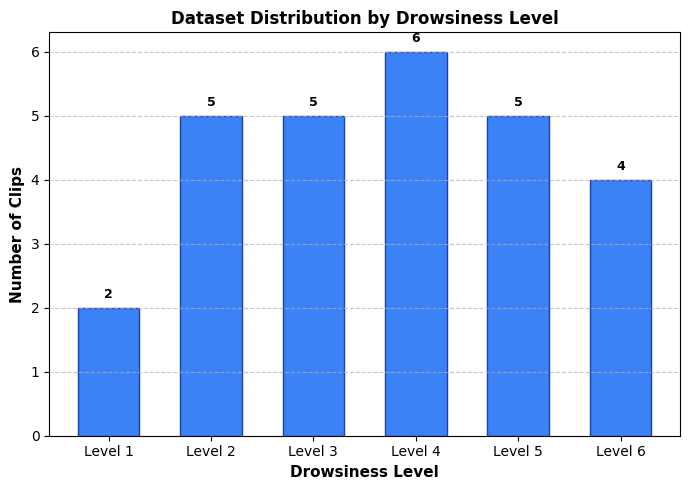

In [6]:
import matplotlib.pyplot as plt

# Prepare data for Drowsiness Level distribution
sorted_levels = sorted(level_counts.keys())
level_vals = [level_counts[lvl] for lvl in sorted_levels]

plt.figure(figsize=(7, 5))
bars1 = plt.bar([f"Level {lvl}" for lvl in sorted_levels], level_vals, color='#3b82f6', edgecolor='#1e40af', width=0.6)

plt.title("Dataset Distribution by Drowsiness Level", fontsize=12, fontweight='bold')
plt.xlabel("Drowsiness Level", fontsize=11, fontweight='bold')
plt.ylabel("Number of Clips", fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, str(height), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization - Total Duration by Drowsiness Level

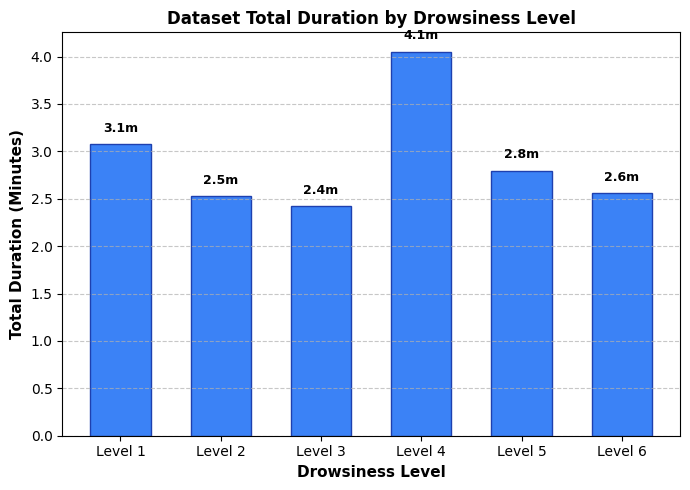

In [7]:
import matplotlib.pyplot as plt

# Prepare data for Drowsiness Level duration distribution (converted to minutes)
sorted_levels = sorted(level_durations.keys())
level_vals_minutes = [level_durations[lvl] / 60.0 for lvl in sorted_levels]

plt.figure(figsize=(7, 5))
bars1 = plt.bar([f"Level {lvl}" for lvl in sorted_levels], level_vals_minutes, color='#3b82f6', edgecolor='#1e40af', width=0.6)

plt.title("Dataset Total Duration by Drowsiness Level", fontsize=12, fontweight='bold')
plt.xlabel("Drowsiness Level", fontsize=11, fontweight='bold')
plt.ylabel("Total Duration (Minutes)", fontsize=11, fontweight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f"{height:.1f}m", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

## Visualization - Subject Distribution


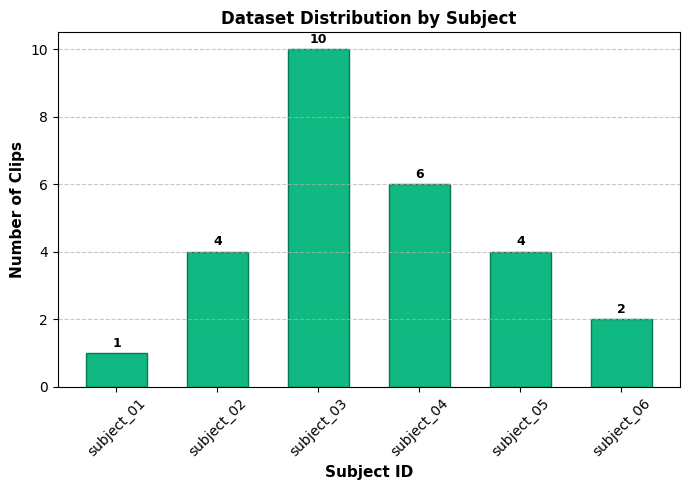

[SUCCESS] Successfully rendered all exploratory distribution charts for 27 clips.


In [8]:
# Prepare data for Subject distribution
sorted_subjects = sorted(subject_counts.keys())
subject_vals = [subject_counts[subj] for subj in sorted_subjects]

plt.figure(figsize=(7, 5))
bars2 = plt.bar(sorted_subjects, subject_vals, color='#10b981', edgecolor='#047857', width=0.6)

plt.title("Dataset Distribution by Subject", fontsize=12, fontweight='bold')
plt.xlabel("Subject ID", fontsize=11, fontweight='bold')
plt.ylabel("Number of Clips", fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, str(height), ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"[SUCCESS] Successfully rendered all exploratory distribution charts for {len(video_files)} clips.")

## Visualization - Total Duration by Subject

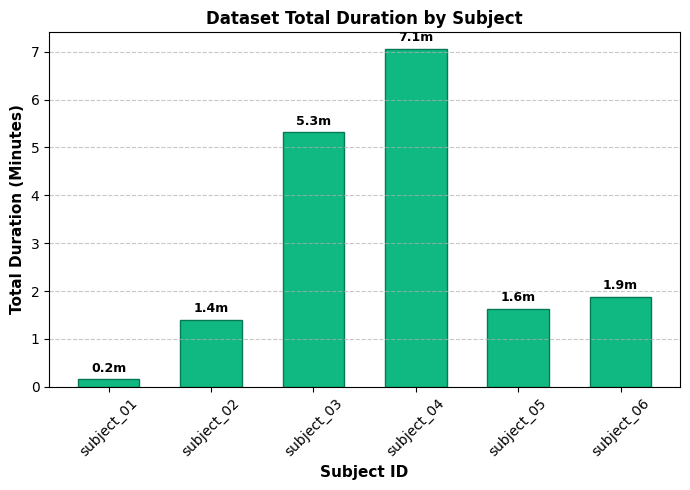

[SUCCESS] Successfully rendered subject duration distribution chart.


In [9]:
import matplotlib.pyplot as plt

# Prepare data for Subject duration distribution (converted to minutes)
sorted_subjects = sorted(subject_durations.keys())
subject_vals_minutes = [subject_durations[subj] / 60.0 for subj in sorted_subjects]

plt.figure(figsize=(7, 5))
bars2 = plt.bar(sorted_subjects, subject_vals_minutes, color='#10b981', edgecolor='#047857', width=0.6)

plt.title("Dataset Total Duration by Subject", fontsize=12, fontweight='bold')
plt.xlabel("Subject ID", fontsize=11, fontweight='bold')
plt.ylabel("Total Duration (Minutes)", fontsize=11, fontweight='bold')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, height + 0.1, f"{height:.1f}m", ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"[SUCCESS] Successfully rendered subject duration distribution chart.")

#  Media Pipe Model Setup & Feature Engineering & Dataset Assembly Pipeline Orchestration


## Dataset Assembly Pipeline Orchestration

This section turns raw `.mp4` clips into structured artifacts for LSTM training.

### The Processing Logic:
1. **Feature Extraction:** MediaPipe extracts landmarks and blendshapes at 10 FPS.
2. **Stream Generation:** The pipeline slices the continuous data into overlapping "streams" (1s–6s windows).
3. **Quality Gate:** The script checks index 6 (`ear_mar_valid`) of every frame in a window. If any frame is marked as invalid (face lost), the entire window is dropped.
4. **Indexing:** Metadata is generated to map every individual `.npy` stream back to its original clip and subject.

## Model Media Pipe Setup & Installing Dependencies



Before any feature extraction can run, a pretrained MediaPipe FaceLandmarker model bundle must exist inside models_folder. This section is idempotent and safe to re-run: it checks for an existing model first, and only downloads one if missing — so once it has run once for a given Google Drive, later runs (or other notebooks sharing the same Argus/models/ folder) reuse the cached file instead of re-downloading.

### Downloading and Setting Up the MediaPipe Model Bundle
1. Install Dependencies: Run the installation command to ensure `mediapipe` and `opencv-python` are available in your environment.

2. Define Directory & Path: Set your target directory (`models_folder`) and verify or create it.

3. Download and Move Model: Check if the pretrained `MediaPipe` `FaceLandmarker` model bundle exists, download it if missing, and move/save it into `models_folder`.


In [10]:
!pip install mediapipe opencv-python

In [11]:
# Verify that the model exist
!ls -l {models_folder}

total 15941
-rw------- 1 root root 1783206 Aug  5 02:30 best_lstm_model.keras
-rw------- 1 root root 3758596 Jul 26 16:57 face_landmarker_quantized.task
-rw------- 1 root root 3758596 Jul 25 21:31 face_landmarker.task
-rw------- 1 root root    1103 Aug  5 02:21 feature_scaler_20260805_0220.joblib
-rw------- 1 root root 1783206 Aug  5 02:31 lstm_drowsiness_20260805_0222.keras
-rw------- 1 root root       0 Aug 10 04:14 lstm_geometric_feature_model_20260810_0319.keras
-rw------- 1 root root 5236761 Aug  5 02:21 rf_classifier_20260805_0220.joblib


In [12]:
import urllib.request

media_pipe_url = "https://storage.googleapis.com/mediapipe-models/face_landmarker/face_landmarker/float16/latest/face_landmarker.task"
media_pipe_filename = "face_landmarker.task"
media_pipe_path = os.path.join(models_folder, media_pipe_filename)

# Download the model only if it doesn't already exist and catch any errors
if not os.path.exists(media_pipe_path):
    print(f"Downloading MediaPipe Face Landmarker model to {media_pipe_path}...")
    try:
        urllib.request.urlretrieve(media_pipe_url, media_pipe_path)
        print("Download complete.")
    except Exception as e:
        raise RuntimeError(f"Failed to download the MediaPipe model from {media_pipe_url}. Error: {e}")
else:
    print(f"Model already exists at {media_pipe_path}. Skipping download.")

Model already exists at /content/drive/MyDrive/Argus/models/face_landmarker.task. Skipping download.


### # MediaPipe Face Landmarker Quantization -- (Still Working on it)



This subsection implements the workflow for the **Argus** drowsiness detection project, focusing on downloading, extracting, and optimizing the MediaPipe Face Landmarker model for deployment.

1. Installing the AI quantizer library

In [13]:
# !pip install -q ai-edge-quantizer

2. Extract the `.task` bundle (it is a ZIP archive)

In [14]:
# import shutil
# import zipfile

# extract_dir = "extracted_task"
# if os.path.exists(extract_dir):
#     shutil.rmtree(extract_dir)   # clean up previous extraction

# with zipfile.ZipFile(media_pipe_path, 'r') as zip_ref:
#     zip_ref.extractall(extract_dir)

# print(f"Extracted contents to {extract_dir}/")
# !ls -lh {extract_dir}

3. Locate all TFLite models inside the extracted folder

In [15]:
# # Build the full paths
# model_paths = {
#     "face_detector": os.path.join(extract_dir, "face_detector.tflite"),
#     "face_landmarks": os.path.join(extract_dir, "face_landmarks_detector.tflite"),
#     "face_blendshapes": os.path.join(extract_dir, "face_blendshapes.tflite"),
# }

# # Validate all exist before starting
# missing = [name for name, path in model_paths.items() if not os.path.exists(path)]
# if missing:
#     raise FileNotFoundError(
#         f"The following required TFLite models are missing from '{extract_dir}': {', '.join(missing)}"
#     )

4. Quantize the TFLite modeles using `ai_edge_quantizer` and replace them.

In [16]:
# from ai_edge_quantizer import quantizer, recipe
# import shutil
# import os

# # Using the dynamic_wi8_afp32 recipe to achieve INT8 quantization.
# # This reduces weight precision to 8-bit integers while maintaining activations in float32,
# # which is the targeted optimization for the Argus project deployment.
# for name, path in model_paths.items():
#     print(f"Quantizing {name} to INT8 (Dynamic)...")
#     qt = quantizer.Quantizer(path)

#     # Load the dynamic INT8 quantization recipe
#     qt.load_quantization_recipe(recipe.dynamic_wi8_afp32())

#     # Define the temporary output path for the INT8 model
#     quantized_temp = f"{name}_dynamic_int8.tflite"
#     if os.path.exists(quantized_temp):
#         os.remove(quantized_temp)

#     # Execute the quantization and export
#     qt.quantize().export_model(quantized_temp)

#     # Replace the original file in the extracted folder with the INT8 version
#     shutil.move(quantized_temp, path)
#     print(f"  Successfully replaced {path} with dynamic INT8 version.")

6. Repackage the folder into a new `.task` file (ZIP with no compression)

In [17]:
# new_task_path = os.path.join(models_folder, "face_landmarker_quantized.task")
# if os.path.exists(new_task_path):
#     os.remove(new_task_path)

# with zipfile.ZipFile(new_task_path, 'w', zipfile.ZIP_STORED) as zipf:
#     for root, dirs, files in os.walk(extract_dir):
#         for file in files:
#             full_path = os.path.join(root, file)
#             arcname = os.path.relpath(full_path, extract_dir)
#             zipf.write(full_path, arcname)

# print(f"✅ Quantized .task file created: {new_task_path}")
# print(f"   Size: {os.path.getsize(new_task_path):,} bytes")

7. Quick validation – load the quantized model with MediaPipe

In [18]:
# from mediapipe.tasks import python
# from mediapipe.tasks.python import vision

# base_options = python.BaseOptions(model_asset_path=new_task_path)
# options = vision.FaceLandmarkerOptions(
#     base_options=base_options,
#     running_mode=vision.RunningMode.IMAGE,
#     num_faces=1,
#     min_face_detection_confidence=0.5
# )
# detector = vision.FaceLandmarker.create_from_options(options)

# print("✅ Quantized model loaded successfully!")

### Test MediaPipe Face Landmarker on a Random Frame

First, let's import the necessary libraries and set up the `FaceLandmarker` for image mode, as we'll be processing a single static image.

In [19]:
import random
import cv2
import os
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# Fix: Explicitly define base_options using the path resolved in the download step
base_options = mp_python.BaseOptions(model_asset_path=os.path.abspath(media_pipe_path))

# Creating new options for IMAGE running mode
image_landmarker_options = vision.FaceLandmarkerOptions(
    base_options=base_options,
    running_mode=vision.RunningMode.IMAGE,
    num_faces=1,
    min_face_detection_confidence=0.5,
    min_face_presence_confidence=0.5,
    min_tracking_confidence=0.5,
    output_face_blendshapes=True,
    output_facial_transformation_matrixes=True,
)

# Create the FaceLandmarker detector instance
detector = vision.FaceLandmarker.create_from_options(image_landmarker_options)

print("✅ MediaPipe FaceLandmarker detector initialized for IMAGE mode.")

✅ MediaPipe FaceLandmarker detector initialized for IMAGE mode.


Next, we'll randomly select one of your video files and then pick a random frame from it. This frame will be used to test the Face Landmarker.

Selected video for test: /content/drive/MyDrive/Argus/dataset/raw_videos/subject_03/level_6_clip_03.mp4
Selected random frame index: 46


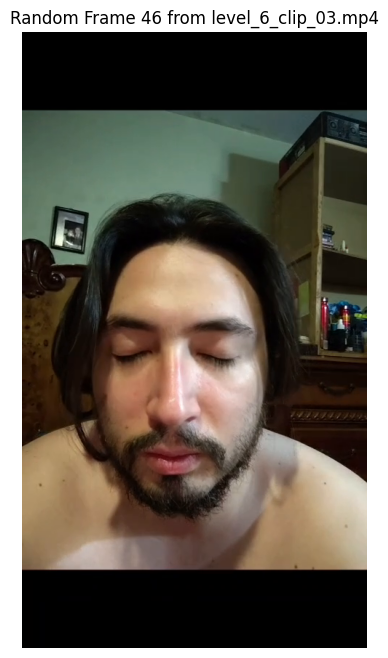

✅ Random frame selected and displayed.


In [20]:
# Randomly select a video file
selected_video_path = random.choice(video_files)
print(f"Selected video for test: {selected_video_path}")

# Open the video file
cap = cv2.VideoCapture(selected_video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {selected_video_path}")

# Get total frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if frame_count == 0:
    raise ValueError(f"Video file {selected_video_path} has no frames.")

# Select a random frame index
random_frame_idx = random.randint(0, frame_count - 1)
print(f"Selected random frame index: {random_frame_idx}")

# Set the video capture to the random frame
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)

# Read the frame
ret, bgr_frame = cap.read()
cap.release()

if not ret:
    raise Exception(f"Failed to read frame {random_frame_idx} from {selected_video_path}")

# Display the raw selected frame
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title(f"Random Frame {random_frame_idx} from {os.path.basename(selected_video_path)}")
plt.axis('off')
plt.show()

print("✅ Random frame selected and displayed.")

Now we'll run the `FaceLandmarker` detector on the selected frame. The `detector` will identify faces and extract facial landmarks, blendshapes, and the head pose transformation matrix.

In [21]:
# Convert the OpenCV BGR frame to RGB and then to a MediaPipe Image object
rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

# Perform face landmark detection
detection_result = detector.detect(mp_image)

if detection_result.face_landmarks:
    print(f"✅ Face(s) detected: {len(detection_result.face_landmarks)}")
    # The first face's blendshapes can be accessed via: detection_result.face_blendshapes[0]
    # And transformation matrix via: detection_result.facial_transformation_matrixes[0]
else:
    print("⚠️ No face detected in the selected frame.")

✅ Face(s) detected: 1


Finally, let's visualize the detected landmarks on the original frame. We'll use MediaPipe's drawing utilities for this.

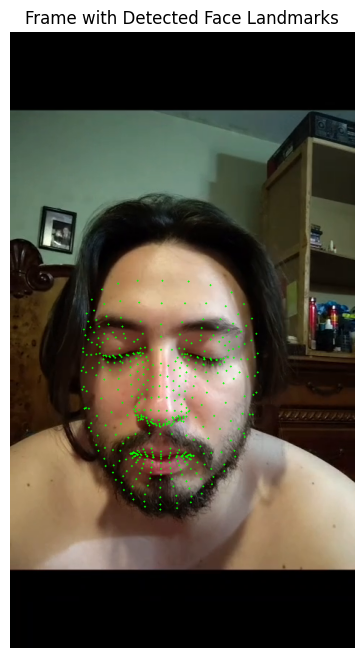

✅ Annotated frame displayed.


In [22]:
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks.python import vision

# Use the existing detector (from your previous cells)
# detector is already created

# Convert frame and detect (assuming detection_result is already available)
# If not, run detection again:
# rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
# mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)
# detection_result = detector.detect(mp_image)

# Make a copy of the frame to annotate
annotated_frame = bgr_frame.copy()
height, width, _ = annotated_frame.shape

if detection_result.face_landmarks:
    # Get the first face's landmarks
    landmarks = detection_result.face_landmarks[0]  # list of NormalizedLandmark

    # Draw each landmark as a small circle
    for lm in landmarks:
        x = int(lm.x * width)
        y = int(lm.y * height)
        cv2.circle(annotated_frame, (x, y), 1, (0, 255, 0), -1)   # green dots

    # Optionally, draw connections (tesselation) – you can import the connection list
    # from the old API without needing the full solutions module:
    try:
        from mediapipe.solutions.face_mesh_connections import FACEMESH_TESSELATION
    except ImportError:
        # Fallback: define a minimal set of connections (or skip)
        FACEMESH_TESSELATION = []

    # Draw connections as lines (if available)
    for connection in FACEMESH_TESSELATION:
        idx1, idx2 = connection
        # Ensure indices are valid
        if idx1 < len(landmarks) and idx2 < len(landmarks):
            x1 = int(landmarks[idx1].x * width)
            y1 = int(landmarks[idx1].y * height)
            x2 = int(landmarks[idx2].x * width)
            y2 = int(landmarks[idx2].y * height)
            cv2.line(annotated_frame, (x1, y1), (x2, y2), (0, 255, 0), 1)

    # Display the annotated frame
    plt.figure(figsize=(10, 8))
    plt.imshow(cv2.cvtColor(annotated_frame, cv2.COLOR_BGR2RGB))
    plt.title("Frame with Detected Face Landmarks")
    plt.axis('off')
    plt.show()
    print("✅ Annotated frame displayed.")
else:
    print("No face landmarks to draw.")

## Feature Extraction per frame

1. FaceLandmaker initialization & Landmark Index Constnats
2. Geometric Ratio Tensor Layer For Functions (EAR, MAR, Head Pose)

### 1. FaceLandmarker Initialization & Landmark Index Constants



To ensure temporal consistency and avoid state-tracking errors across different video files, we configure the `FaceLandmarker` options to use `VIDEO` running mode. While the configuration is defined globally in `face_landmarker_options`, the **FeatureExtractionPipeline** now instantiates a fresh detector for every video processed. This resets the internal MediaPipe timestamp clock, preventing errors related to non-monotonic timestamps when moving from the end of one clip to the start of another.

Key configuration highlights:

*   **Blendshapes & Transformation Matrix:** Both are enabled to extract 52 facial action units and head pose (pitch/yaw/roll) simultaneously.
*   **Landmark Indices:** `left_eye_ear_idx`, `right_eye_ear_idx`, and `mouth_mar_idx` use standard MediaPipe FaceMesh topology (6-point eyes, 4-point mouth) which remains stable across all subjects.
*   **Sampling Strategy:** `sampling_fps` (defaulting to 10) ensures the training data matches the temporal distribution achievable on the target Raspberry Pi 5 hardware.

This setup reuses the `media_pipe_path` resolved in the previous download step.

In [23]:
import numpy as np
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision

# --- FaceLandmarker configuration (media_pipe_path already resolved by the download step) ---
base_options = mp_python.BaseOptions(model_asset_path=os.path.abspath(media_pipe_path))
face_landmarker_options = vision.FaceLandmarkerOptions(
    base_options = base_options,
    running_mode = vision.RunningMode.VIDEO,
    num_faces = 1,
    min_face_detection_confidence = 0.5,
    min_face_presence_confidence = 0.5,
    min_tracking_confidence = 0.5,
    output_face_blendshapes = True,
    output_facial_transformation_matrixes = True,
)

print("FaceLandmarker configuration and constants ready.")

FaceLandmarker configuration and constants ready.


### 2. Geometric Ratio Tensor Layer For Functions (EAR, MAR, Head Pose)

Here we define the TensorFlow layer that we will use both during dataset building (for consistency) and later when we assemble the LSTM model.

The geometric helper functions needed for computing (`EAR`, `MAR`, `Head Pose`)

To enable export to a single `.tflite` file — and to keep feature extraction identical between dataset creation and inference — we now implement an exact TensorFlow‑native counterpart: **`GeometricRatioFeatureLayer`**. This layer performs the same geometric calculations using `tf` operations.

In [24]:
import tensorflow as tf
import numpy as np

class GeometricRatioFeatureLayer(tf.keras.layers.Layer):
    """
    TensorFlow-native counterpart to compute_ear, compute_mar, and rotation_matrix_to_euler.
    Inputs:
        landmarks_xy : (batch, 478, 2)   -- normalized (x, y) coordinates
        rotation_matrix : (batch, 3, 3)  -- top‑left 3×3 block of the facial transformation matrix
    Returns:
        (batch, 7) : [EAR_left, EAR_right, MAR, pitch, yaw, roll, ear_mar_valid]
        where pitch, yaw, roll are in degrees, and ear_mar_valid is 1 if the head pose is within
        the validity threshold, else 0.
    """
    def __init__(self, pose_validity_threshold_deg=20.0, **kwargs):
        super().__init__(**kwargs)
        self.pose_validity_threshold_deg = pose_validity_threshold_deg

        # Fixed landmark indices (same as used in the NumPy functions)
        self.left_eye_idx  = tf.constant([33, 160, 158, 133, 153, 144], dtype=tf.int32)
        self.right_eye_idx = tf.constant([362, 385, 387, 263, 373, 380], dtype=tf.int32)
        self.mouth_idx     = tf.constant([61, 291, 13, 14], dtype=tf.int32)

    def get_config(self):
        config = super().get_config()
        config.update({
            "pose_validity_threshold_deg": self.pose_validity_threshold_deg,
        })
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

    @staticmethod
    def _dist(points, i, j):
        """Euclidean distance between two selected points, batch‑safe."""
        a = points[..., i, :]
        b = points[..., j, :]
        return tf.norm(a - b, axis=-1)

    def _ear(self, landmarks, idx):
        """
        Eye Aspect Ratio.
        idx convention: [left_corner, top_1, top_2, right_corner, bottom_2, bottom_1]
        """
        p = tf.gather(landmarks, idx, axis=-2)          # shape: (..., 6, 2)
        vertical = self._dist(p, 1, 5) + self._dist(p, 2, 4)
        horizontal = 2.0 * self._dist(p, 0, 3)
        return tf.math.divide_no_nan(vertical, horizontal)

    def _mar(self, landmarks, idx):
        """
        Mouth Aspect Ratio.
        idx convention: [left_corner, right_corner, upper_lip, lower_lip]
        """
        p = tf.gather(landmarks, idx, axis=-2)          # shape: (..., 4, 2)
        vertical = self._dist(p, 2, 3)
        horizontal = self._dist(p, 0, 1)
        return tf.math.divide_no_nan(vertical, horizontal)

    @staticmethod
    def _rotation_matrix_to_euler(R):
        """
        Convert a 3×3 rotation matrix to pitch, yaw, roll in degrees.
        Handles the gimbal‑lock singularity gracefully.
        """
        r00, r10, r20 = R[..., 0, 0], R[..., 1, 0], R[..., 2, 0]
        r21, r22 = R[..., 2, 1], R[..., 2, 2]
        r11, r12 = R[..., 1, 1], R[..., 1, 2]

        sy = tf.sqrt(r00**2 + r10**2)
        singular = sy < 1e-6

        pitch_reg = tf.atan2(r21, r22)
        yaw       = tf.atan2(-r20, sy)
        roll_reg  = tf.atan2(r10, r00)

        pitch_sing = tf.atan2(-r12, r11)
        roll_sing  = tf.zeros_like(roll_reg)

        pitch = tf.where(singular, pitch_sing, pitch_reg)
        roll  = tf.where(singular, roll_sing, roll_reg)

        rad2deg = 180.0 / np.pi
        return pitch * rad2deg, yaw * rad2deg, roll * rad2deg

    def call(self, landmarks_xy, rotation_matrix):
        ear_left  = self._ear(landmarks_xy, self.left_eye_idx)
        ear_right = self._ear(landmarks_xy, self.right_eye_idx)
        mar       = self._mar(landmarks_xy, self.mouth_idx)

        pitch, yaw, roll = self._rotation_matrix_to_euler(rotation_matrix)

        ear_mar_valid = tf.cast(
            tf.logical_and(
                tf.abs(yaw) < self.pose_validity_threshold_deg,
                tf.abs(pitch) < self.pose_validity_threshold_deg
            ),
            tf.float32
        )

        return tf.stack([ear_left, ear_right, mar, pitch, yaw, roll, ear_mar_valid], axis=-1)

print("✅ GeometricRatioFeatureLayer (TensorFlow-native geometric ratios) defined successfully.")

✅ GeometricRatioFeatureLayer (TensorFlow-native geometric ratios) defined successfully.


## Pipeline Orchestration: Connecting MediaPipe, Ratio Layer, and Video Processing

### 1. Pipeline Configuration Constants





This subsection defines the global parameters that govern the feature extraction and windowing logic. Adjusting these values allows you to experiment with different temporal resolutions and window sizes without modifying the core pipeline code.

In [25]:
# --- Pipeline Configuration Constants ---
sampling_fps = 10                     # Target extraction rate (frames per second)
min_context_sec = 1                  # Minimum window size
max_context_sec = 6.0                # Maximum window size
pose_validity_threshold_deg = 20.0    # Pitch/Yaw range for valid EAR/MAR

# Dynamic window configuration: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0]
# This creates the array of durations for the LSTM streams
window_configs = [float(x) for x in range(int(min_context_sec), int(max_context_sec) + 1)]
stride_sec = 1.0  # Slide the window by 1 second steps

print(f"✅ Pipeline constants initialized.")
print(f"   Sampling: {sampling_fps} FPS")
print(f"   Window Streams to generate: {window_configs} seconds")

# --- Fixed landmark index sets for EAR/MAR ---
left_eye_ear_idx  = [33, 160, 158, 133, 153, 144]
right_eye_ear_idx = [362, 385, 387, 263, 373, 380]
mouth_mar_idx     = [61, 291, 13, 14]

✅ Pipeline constants initialized.
   Sampling: 10 FPS
   Window Streams to generate: [1.0, 2.0, 3.0, 4.0, 5.0, 6.0] seconds


### 2. Pipeline Orchestration Definition

Now we define the core orchestration logic that processes a raw video and produces the feature matrix.

**Components:**
- **MediaPipe detector** – extracts landmarks, blendshapes, and the 3×3 rotation matrix per frame.
- **`GeometricRatioFeatureLayer`** – computes EAR, MAR, and head‑pose angles (pitch, yaw, roll) from the raw landmarks and rotation matrix.
- **Video reader** – uses OpenCV to sample frames at the target `sampling_fps`.

The pipeline returns a NumPy array of shape `(num_frames, 59)` where each row consists of:
- 7 base features: `[EAR_left, EAR_right, MAR, pitch, yaw, roll, ear_mar_valid]`
- 52 blendshape scores (MediaPipe’s ARKit‑style coefficients)

In [26]:
import cv2
import numpy as np
import tensorflow as tf
from mediapipe.tasks.python import vision
import mediapipe as mp
from tqdm.auto import tqdm

class FeatureExtractionPipeline:
    def __init__(self, face_landmarker_options: vision.FaceLandmarkerOptions,
                 ratio_layer: GeometricRatioFeatureLayer,
                 sampling_fps: int = 10):
        self.face_landmarker_options = face_landmarker_options
        self.ratio_layer = ratio_layer
        self.sampling_fps = sampling_fps

    def process_video(self, video_path: str):
        detector_local = vision.FaceLandmarker.create_from_options(self.face_landmarker_options)
        cap = cv2.VideoCapture(video_path)
        if not cap.isOpened():
            detector_local.close()
            raise IOError(f"Cannot open video: {video_path}")

        src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        frame_stride = max(1, round(src_fps / self.sampling_fps))

        rows = []
        dropped_frames = 0
        frame_idx = 0

        # Use tqdm for a local progress bar per video
        pbar = tqdm(total=total_frames, desc=f"Processing {os.path.basename(video_path)[:20]}...", leave=False)

        while True:
            ret, frame_bgr = cap.read()
            if not ret:
                break

            if frame_idx % frame_stride == 0:
                frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
                timestamp_ms = int(frame_idx * (1000.0 / src_fps))

                result = detector_local.detect_for_video(mp_image, timestamp_ms)

                if result.face_landmarks:
                    lm = result.face_landmarks[0]
                    landmarks_xy = tf.constant([[p.x, p.y] for p in lm], dtype=tf.float32)
                    R = np.array(result.facial_transformation_matrixes[0])[:3, :3] if result.facial_transformation_matrixes else np.eye(3, dtype=np.float32)
                    R_tf = tf.constant(R, dtype=tf.float32)

                    ratios = self.ratio_layer(landmarks_xy[tf.newaxis, ...], R_tf[tf.newaxis, ...]).numpy()[0]
                    bs_dict = {b.category_name: b.score for b in result.face_blendshapes[0]} if result.face_blendshapes else {}
                    bs_scores = [bs_dict.get(name, 0.0) for name in self.ratio_layer.blendshape_names]

                    row = np.concatenate([ratios, bs_scores]).astype(np.float32)
                    rows.append(row)
                else:
                    dropped_frames += 1
                    # Append a dummy row with validity=0 to maintain temporal consistency
                    # This allows the window slicer to identify and drop bad windows later
                    dummy = np.zeros(7 + 51, dtype=np.float32) # ear_mar_valid is at index 6
                    rows.append(dummy)

            frame_idx += 1
            pbar.update(1)

        pbar.close()
        cap.release()
        detector_local.close()

        return (np.array(rows, dtype=np.float32), dropped_frames) if rows else (None, 0)

### 3. Pipeline Orchestration Run & Dataset Creation

This section orchestrates the feature extraction pipeline, processing each raw video clip to generate a NumPy array (`.npy`) of features and a master `metadata.csv` file. This process is crucial for transforming raw video data into a structured dataset ready for model training.

### Initial Setup and Blendshape Names

First, we ensure that necessary variables like `metadata_path` are defined. A critical step is defining the `blendshape_names` list, which enumerates all 52 ARKit-style blendshape scores that MediaPipe can output. This list ensures a consistent order for our feature vectors, even if certain blendshapes are not present in a given frame.

In [27]:
# --- Ensure required variables are defined ---
# (These should already exist, but we double-check)
metadata_path = os.path.join(processed_folder, "metadata.csv")

# --- Ensure the ratio layer has the blendshape names (if not already defined) ---
if not hasattr(GeometricRatioFeatureLayer, 'blendshape_names'):
    GeometricRatioFeatureLayer.blendshape_names = [
        "browDownLeft", "browDownRight", "browInnerUp", "browOuterUpLeft", "browOuterUpRight",
        "cheekPuff", "cheekSquintLeft", "cheekSquintRight",
        "eyeBlinkLeft", "eyeBlinkRight",
        "eyeLookDownLeft", "eyeLookDownRight", "eyeLookInLeft", "eyeLookInRight",
        "eyeLookOutLeft", "eyeLookOutRight", "eyeLookUpLeft", "eyeLookUpRight",
        "eyeSquintLeft", "eyeSquintRight", "eyeWideLeft", "eyeWideRight",
        "jawForward", "jawLeft", "jawOpen", "jawRight",
        "mouthClose", "mouthDimpleLeft", "mouthDimpleRight", "mouthFrownLeft", "mouthFrownRight",
        "mouthFunnel", "mouthLeft", "mouthLowerDownLeft", "mouthLowerDownRight",
        "mouthPressLeft", "mouthPressRight", "mouthPucker", "mouthRight",
        "mouthRollLower", "mouthRollUpper", "mouthShrugLower", "mouthShrugUpper",
        "mouthSmileLeft", "mouthSmileRight", "mouthStretchLeft", "mouthStretchRight",
        "mouthUpperUpLeft", "mouthUpperUpRight", "noseSneerLeft", "noseSneerRight",
    ]

### Instantiate Components and Dataset Reset Option

Here, we initialize the `FaceLandmarker` detector, the `GeometricRatioFeatureLayer` (which calculates EAR, MAR, and head pose from landmarks), and the `FeatureExtractionPipeline`.

Crucially, a `reset_dataset` flag is introduced. If set to `True`, this will delete all previously processed `.npy` feature files and the `metadata.csv`, allowing for a complete rebuild of the dataset. This is useful when you want to re-run the entire pipeline or update feature extraction logic.

In [28]:
# --- Instantiate components ---
# The global 'detector' variable for VIDEO mode is removed here.
# FeatureExtractionPipeline will now create its own detector instance per video.
ratio_layer = GeometricRatioFeatureLayer(pose_validity_threshold_deg=pose_validity_threshold_deg)
pipeline = FeatureExtractionPipeline(face_landmarker_options, ratio_layer, sampling_fps=sampling_fps)

In [29]:
import shutil
import os

# --- Safety flag: set to True to delete existing dataset and rebuild from scratch ---
reset_dataset = False  # Change to True when you want to rebuild

# --- Reset if requested ---
if reset_dataset:
    # Completely remove the features folder and metadata file
    if os.path.exists(features_folder):
        shutil.rmtree(features_folder)
        print(f"🧹 Features directory removed: {features_folder}")

    if os.path.exists(metadata_path):
        os.remove(metadata_path)
        print(f"🧹 Metadata file removed: {metadata_path}")

    # Recreate the features folder
    os.makedirs(features_folder, exist_ok=True)
    print("✨ Clean features directory recreated. Ready for fresh extraction.")

### Video Processing Loop

This is the core of the pipeline where each video file is processed. For each video:

1.  **Metadata Extraction:** The subject and drowsiness level are extracted from the file path and name.
2.  **Feature Extraction:** The `pipeline.process_video` method is called to extract features from the video frames.
3.  **Handling Skipped Videos:** If no face is detected in any frame or processing fails, the video is skipped and logged.
4.  **Saving Features:** If features are successfully extracted, they are saved as a `.npy` file in the `features_folder`.
5.  **Collecting Metadata:** Information about the processed clip (subject, level, frame count, duration, feature path) is stored in a list of dictionaries (`rows`).

In [30]:
import re
import numpy as np
import os
from tqdm.auto import tqdm

# Only run the processing loop if reset_dataset is True
if reset_dataset:
    rows = []
    skipped = []

    # Overall progress bar for the entire file list
    main_pbar = tqdm(video_files, desc="Total Dataset Progress")

    for video_path in main_pbar:
        filename = os.path.basename(video_path)
        subject = os.path.basename(os.path.dirname(video_path))

        match = re.search(r'level_(\d+)', filename, re.IGNORECASE)
        if not match:
            skipped.append((filename, "could not parse level"))
            continue
        level = int(match.group(1))

        # Process video
        result = pipeline.process_video(video_path)

        # Safety check: Handle return values regardless of if it's a tuple or single array
        if result is None:
            skipped.append((filename, "processing failure"))
            continue

        if isinstance(result, tuple):
            full_features, drop_count = result[0], result[1]
        else:
            full_features, drop_count = result, "N/A"

        if full_features is None:
            skipped.append((filename, "no face data found"))
            continue

        valid_windows_saved = 0

        # Iterate through each window duration defined in constants (1s to 6s)
        for win_sec in window_configs:
            win_size = int(win_sec * sampling_fps)
            stride = int(stride_sec * sampling_fps)

            # Slide the window across the extracted frames
            for start in range(0, len(full_features) - win_size + 1, stride):
                end = start + win_size
                window_data = full_features[start:end]

                # CRITICAL: Check index 6 (ear_mar_valid)
                # If any frame in this window is 0.0 (dummy), the face was lost.
                # We drop the entire stream to avoid training the LSTM on noise.
                if np.any(window_data[:, 6] == 0.0):
                    continue

                # Save the valid window
                clip_stem = os.path.splitext(filename)[0]
                feat_filename = f"{subject}_{clip_stem}_w{win_sec}s_start{start}.npy"
                feat_path = os.path.join(features_folder, feat_filename)

                np.save(feat_path, window_data.astype(np.float32))
                valid_windows_saved += 1

                rows.append({
                    "subject": subject,
                    "level": level,
                    "parent_video": filename,
                    "window_duration_sec": win_sec,
                    "n_frames": win_size,
                    "feature_path": feat_path,
                    "dropped_frames_in_video": drop_count
                })

        main_pbar.set_postfix({"subj": subject, "drops": drop_count, "wins": valid_windows_saved})

    print(f"\nProcessing Complete. Generated {len(rows)} valid window streams.")
else:
    print("\nSkipping video processing as `reset_dataset` is True.")


Skipping video processing as `reset_dataset` is True.


### Writing Metadata CSV and Cleanup

After processing all videos, the collected metadata (`rows`) is written to `metadata.csv`. This CSV file serves as the central index for the entire dataset, linking each clip's features (`.npy` file) to its subject, drowsiness level, and other relevant information.

Finally, the `detector.close()` method is called to release any resources held by the MediaPipe FaceLandmarker.

In [31]:
# --- Write updated metadata CSV ---
import csv

# Update fieldnames to match the windowed structure and include the drop count
fieldnames = ["subject", "level", "parent_video", "window_duration_sec", "n_frames", "feature_path", "dropped_frames_in_video"]

if reset_dataset:
    with open(metadata_path, 'w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        writer.writeheader()
        writer.writerows(rows)

    print(f"\n✅ Dataset built: {len(rows)} window streams written to {metadata_path}")
    if skipped:
        print(f"⚠️  Skipped {len(skipped)} clips:")
        for name, reason in skipped:
            print(f"   - {name}: {reason}")

# Clean up detector
detector.close()

# Statistical Validation & Feature Correlation



Now that we have built the windowed dataset, we need to verify that the features we've extracted (EAR, MAR, Blendshapes, and Pose) actually correlate with the drowsiness labels (1–6). This step is crucial for **feature selection**: we only want to feed the most predictive signals into the LSTM.

In [32]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm # Import tqdm for progress bar

# 1. Load the metadata we just created
df_meta = pd.read_csv(metadata_path)

# 2. To analyze the raw values and for training, we'll use all the .npy files
# and calculate the mean feature vector for each window.
feature_list = []

print("Aggregating window features using ALL data...")
# Use all data instead of sampling
full_df_source = df_meta

# The GeometricRatioFeatureLayer.blendshape_names is a list containing the names of all 52 blendshapes
# The `mean_features` array contains 7 geometric ratios followed by 52 blendshape scores.
# So, blendshape_names[i] corresponds to mean_features[7 + i].

for _, row in tqdm(full_df_source.iterrows(), total=len(full_df_source), desc="Processing all windows for analysis and training"): # Use ALL df_meta data
    data = np.load(row['feature_path'])
    # Calculate the mean across the time dimension for this window
    mean_features = np.mean(data, axis=0)

    res = {"level": row['level'], "subject": row['subject']}
    # Column mapping: 0:EAR_L, 1:EAR_R, 2:MAR, 3:Pitch, 4:Yaw, 5:Roll
    res['EAR_mean'] = (mean_features[0] + mean_features[1]) / 2
    res['MAR'] = mean_features[2]
    res['Pitch'] = mean_features[3]
    res['Yaw'] = mean_features[4]
    res['Roll'] = mean_features[5]

    # Add a few key blendshapes (index in blendshape_names list + 7 for mean_features array)
    res['eyeBlinkLeft'] = mean_features[7 + 8] # Index 8 in blendshape_names
    res['eyeBlinkRight'] = mean_features[7 + 9] # Index 9 in blendshape_names
    res['eyeSquintLeft'] = mean_features[7 + 18] # Index 18 in blendshape_names
    res['eyeSquintRight'] = mean_features[7 + 19] # Index 19 in blendshape_names
    res['jawOpen'] = mean_features[7 + 24]    # Index 24 in blendshape_names
    res['browDownLeft'] = mean_features[7 + 0] # Index 0 in blendshape_names
    res['browDownRight'] = mean_features[7 + 1] # Index 1 in blendshape_names
    res['mouthFunnel'] = mean_features[7 + 31] # Index 31 in blendshape_names
    res['mouthStretchLeft'] = mean_features[7 + 40] # Index 40 in blendshape_names
    res['mouthStretchRight'] = mean_features[7 + 41] # Index 41 in blendshape_names

    feature_list.append(res)

df_full_analysis = pd.DataFrame(feature_list)
print(f"Created df_full_analysis with {len(df_full_analysis)} rows (all available data).")
display(df_full_analysis.head())

Aggregating window features using ALL data...


Processing all windows for analysis and training:   0%|          | 0/3459 [00:00<?, ?it/s]

Created df_full_analysis with 3459 rows (all available data).


,level,subject,EAR_mean,MAR,Pitch,Yaw,Roll,eyeBlinkLeft,eyeBlinkRight,eyeSquintLeft,eyeSquintRight,jawOpen,browDownLeft,browDownRight,mouthFunnel,mouthStretchLeft,mouthStretchRight
0,5,subject_01,0.113906,0.003119,3.022051,1.313258,0.228462,0.336919,0.302512,0.491008,0.341803,0.000621,0.245679,0.167137,0.003489,0.000138,0.005116
1,5,subject_01,0.113585,0.003798,3.712452,-1.228677,0.359371,0.330517,0.316999,0.500929,0.353107,0.000462,0.279260,0.227319,0.003230,0.000112,0.006980
2,5,subject_01,0.104346,0.003032,5.974926,-1.671038,-0.145503,0.378045,0.340294,0.579324,0.368234,0.000623,0.217747,0.173395,0.004295,0.000114,0.005456
3,5,subject_01,0.048358,0.002997,5.126244,-2.074171,0.129975,0.657975,0.625778,0.640548,0.521165,0.000741,0.087382,0.073562,0.005617,0.000151,0.005618
4,5,subject_01,0.103529,0.002378,2.598799,-2.679354,0.721623,0.382296,0.350528,0.512011,0.332782,0.000455,0.205151,0.132882,0.003865,0.000108,0.006387


### Spearman Correlation Heatmap


Since our drowsiness levels (1–6) are **ordinal**, we use Spearman correlation to see which features increase or decrease linearly with sleepiness.

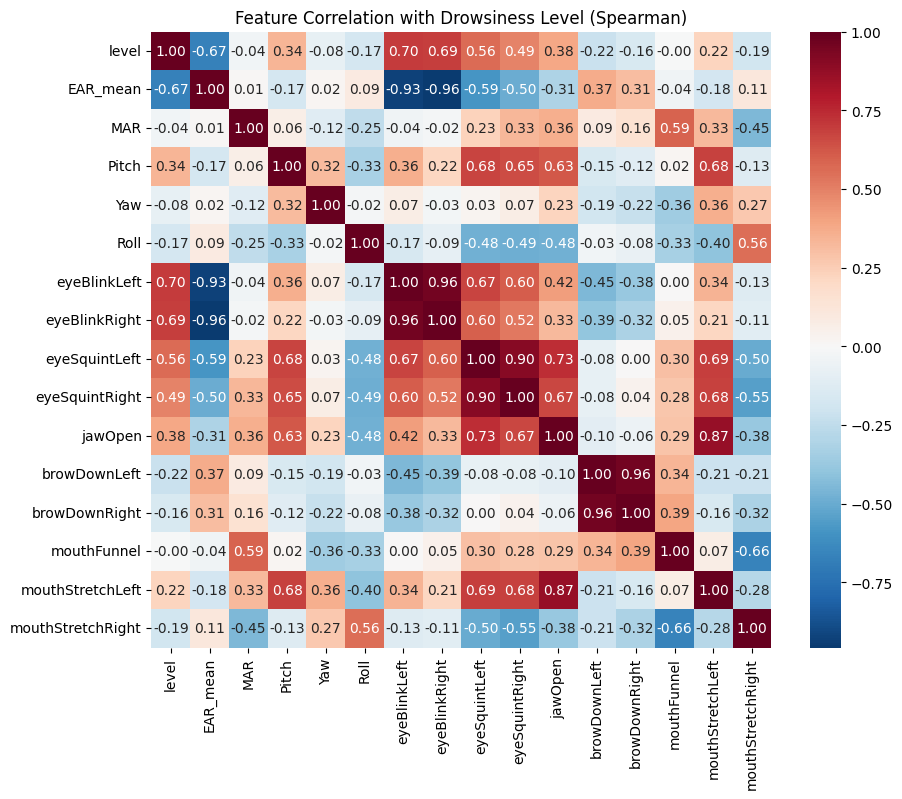

Interpretation: Look for features with high absolute correlation with 'level'.
Negative correlation with EAR is expected (eyes close as level increases).


In [33]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from tqdm.auto import tqdm # Import tqdm for progress bar

# Calculate Spearman correlation
corr = df_full_analysis.drop(columns=['subject']).corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title("Feature Correlation with Drowsiness Level (Spearman)")
plt.show()

print("Interpretation: Look for features with high absolute correlation with 'level'.")
print("Negative correlation with EAR is expected (eyes close as level increases).")

### Statistical Significance (Kruskal-Wallis)


We check if the distribution of EAR significantly differs across the 6 drowsiness levels.

Kruskal-Wallis H-test for EAR across levels:
H-statistic: 1985.2689
p-value: 0.0000e+00

✅ SUCCESS: EAR is statistically different across drowsiness levels.


/tmp/ipykernel_1819/1722701015.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='EAR_mean', data=df_full_analysis, palette='Blues')


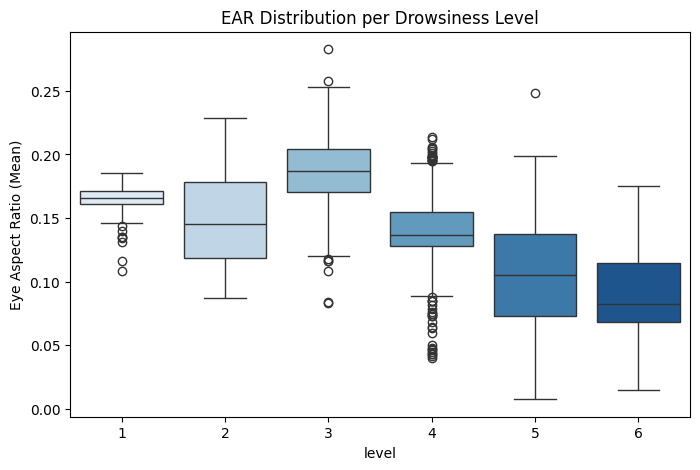

In [34]:
# Group EAR by level
groups = [df_full_analysis[df_full_analysis['level'] == i]['EAR_mean'] for i in range(1, 7)]
groups = [g for g in groups if len(g) > 0] # Filter empty levels

H_stat, p_val = stats.kruskal(*groups)

print(f"Kruskal-Wallis H-test for EAR across levels:")
print(f"H-statistic: {H_stat:.4f}")
print(f"p-value: {p_val:.4e}")

if p_val < 0.05:
    print("\n✅ SUCCESS: EAR is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

# Visualize the trend
plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='EAR_mean', data=df_full_analysis, palette='Blues')
plt.title("EAR Distribution per Drowsiness Level")
plt.ylabel("Eye Aspect Ratio (Mean)")
plt.show()

### Additional Kruskal-Wallis Tests for Feature Validation

Let's continue this validation by applying the Kruskal-Wallis test to `MAR` (Mouth Aspect Ratio), as it's another key indicator related to yawning.

Kruskal-Wallis H-test for MAR across levels:
H-statistic: 476.4055
p-value: 9.8711e-101

✅ SUCCESS: MAR is statistically different across drowsiness levels.


/tmp/ipykernel_1819/3091532779.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='MAR', data=df_full_analysis, palette='Oranges')


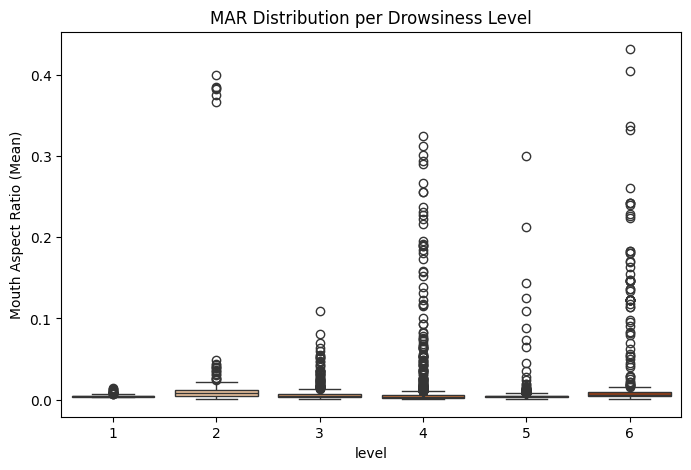

In [35]:
# Group 'MAR' by level
groups_mar = [df_full_analysis[df_full_analysis['level'] == i]['MAR'] for i in range(1, 7)]
groups_mar = [g for g in groups_mar if len(g) > 0] # Filter empty levels

H_stat_mar, p_val_mar = stats.kruskal(*groups_mar)

print(f"Kruskal-Wallis H-test for MAR across levels:")
print(f"H-statistic: {H_stat_mar:.4f}")
print(f"p-value: {p_val_mar:.4e}")

if p_val_mar < 0.05:
    print("\n✅ SUCCESS: MAR is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

# Visualize the trend
plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='MAR', data=df_full_analysis, palette='Oranges')
plt.title("MAR Distribution per Drowsiness Level")
plt.ylabel("Mouth Aspect Ratio (Mean)")
plt.show()

Now, let's examine `eyeBlinkRight`. Changes in blinking patterns are strongly associated with drowsiness, so this feature is crucial to validate.

Kruskal-Wallis H-test for eyeBlinkRight across levels:
H-statistic: 1823.4805
p-value: 0.0000e+00

✅ SUCCESS: eyeBlinkRight is statistically different across drowsiness levels.


/tmp/ipykernel_1819/702843947.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='eyeBlinkRight', data=df_full_analysis, palette='Greens')


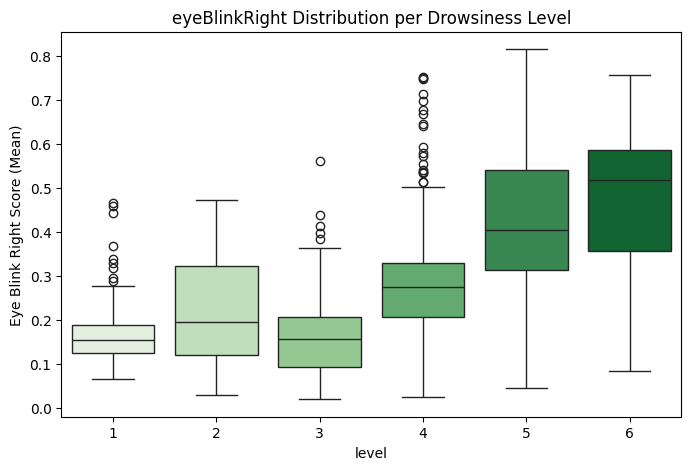

In [36]:
# Group 'eyeBlinkRight' by level
groups_eye_blink = [df_full_analysis[df_full_analysis['level'] == i]['eyeBlinkRight'] for i in range(1, 7)]
groups_eye_blink = [g for g in groups_eye_blink if len(g) > 0] # Filter empty levels

H_stat_eye_blink, p_val_eye_blink = stats.kruskal(*groups_eye_blink)

print(f"Kruskal-Wallis H-test for eyeBlinkRight across levels:")
print(f"H-statistic: {H_stat_eye_blink:.4f}")
print(f"p-value: {p_val_eye_blink:.4e}")

if p_val_eye_blink < 0.05:
    print("\n✅ SUCCESS: eyeBlinkRight is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

# Visualize the trend
plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='eyeBlinkRight', data=df_full_analysis, palette='Greens')
plt.title("eyeBlinkRight Distribution per Drowsiness Level")
plt.ylabel("Eye Blink Right Score (Mean)")
plt.show()

Finally, let's test `mouthFunnel`, another blendshape that could indicate yawning or specific mouth movements related to drowsiness.

Kruskal-Wallis H-test for mouthFunnel across levels:
H-statistic: 709.8032
p-value: 3.7286e-151

✅ SUCCESS: mouthFunnel is statistically different across drowsiness levels.


/tmp/ipykernel_1819/1517536225.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='level', y='mouthFunnel', data=df_full_analysis, palette='Purples')


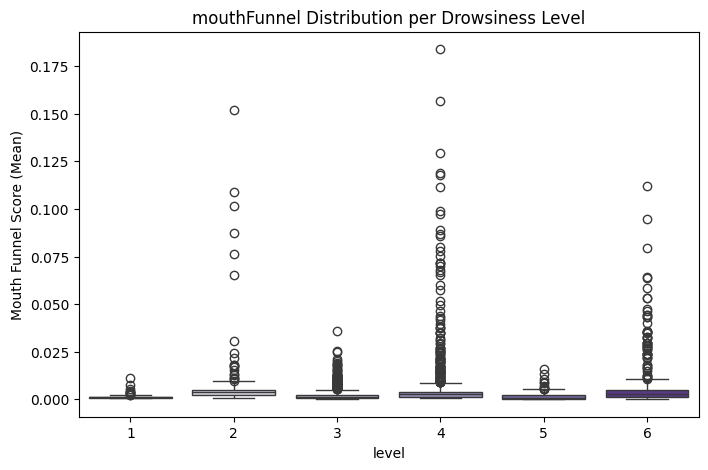

In [37]:
# Group 'mouthFunnel' by level
groups_mouth_funnel = [df_full_analysis[df_full_analysis['level'] == i]['mouthFunnel'] for i in range(1, 7)]
groups_mouth_funnel = [g for g in groups_mouth_funnel if len(g) > 0] # Filter empty levels

H_stat_mouth_funnel, p_val_mouth_funnel = stats.kruskal(*groups_mouth_funnel);

print(f"Kruskal-Wallis H-test for mouthFunnel across levels:")
print(f"H-statistic: {H_stat_mouth_funnel:.4f}")
print(f"p-value: {p_val_mouth_funnel:.4e}")

if p_val_mouth_funnel < 0.05:
    print("\n✅ SUCCESS: mouthFunnel is statistically different across drowsiness levels.")
else:
    print("\n⚠️ WARNING: No significant difference found. Check data labeling or extraction quality.")

# Visualize the trend
plt.figure(figsize=(8, 5))
sns.boxplot(x='level', y='mouthFunnel', data=df_full_analysis, palette='Purples')
plt.title("mouthFunnel Distribution per Drowsiness Level")
plt.ylabel("Mouth Funnel Score (Mean)")
plt.show()

## Comprehensive Feature Correlation with Drowsiness Level

To effectively train our Random Forest classifier, it's crucial to understand which features have the strongest relationship with the `level` of drowsiness. We will now compute the Spearman correlation coefficient for all features in our `df_analysis` DataFrame against the `level` and interpret the results.

In [38]:
# Calculate Spearman correlation for all features with 'level'
correlation_with_level = df_full_analysis.drop(columns=['subject']).corr(method='spearman')['level'].sort_values(ascending=False)

# Exclude 'level' itself from the list
correlation_with_level = correlation_with_level.drop('level')

print("Spearman Correlation with Drowsiness Level (sorted by absolute value):")
print(correlation_with_level.reindex(correlation_with_level.abs().sort_values(ascending=False).index))

Spearman Correlation with Drowsiness Level (sorted by absolute value):
eyeBlinkLeft         0.700902
eyeBlinkRight        0.687098
EAR_mean            -0.669432
eyeSquintLeft        0.558116
eyeSquintRight       0.490219
jawOpen              0.382475
Pitch                0.342359
mouthStretchLeft     0.222432
browDownLeft        -0.221829
mouthStretchRight   -0.191521
Roll                -0.174973
browDownRight       -0.158035
Yaw                 -0.083353
MAR                 -0.039076
mouthFunnel         -0.003615
Name: level, dtype: float64


### Interpretation of Feature Correlations for Random Forest:

Based on the Spearman correlation values, here's an analysis of which features appear to be good candidates for the Random Forest model:

**Strong Positive Correlation (Features increasing with drowsiness):**
*   **`eyeBlinkLeft` / `eyeBlinkRight`**: These show strong positive correlations. As drowsiness increases, individuals might exhibit more frequent or prolonged blinks, or these blendshapes capture a different aspect of eye closure that correlates positively with drowsiness. These are excellent candidates.
*   **`eyeSquintLeft` / `eyeSquintRight`**: These also show a good positive correlation, suggesting squinting might increase with drowsiness or be a compensatory mechanism.
*   **`jawOpen`**: This feature shows a good positive correlation, highly expected as drowsiness often leads to yawning.
*   **`Pitch`**: A moderate positive correlation, suggesting a tendency for the head to tilt forward with increasing drowsiness.

**Strong Negative Correlation (Features decreasing with drowsiness):**
*   **`EAR_mean` (Eye Aspect Ratio)**: This feature exhibits a very strong negative correlation. As drowsiness increases, eyelids tend to close, leading to a lower EAR. This is a primary indicator of sleepiness and is a crucial feature.

**Weak or Moderate Correlation (Potentially less impactful or requiring further investigation):**
*   **`browDownLeft`, `browDownRight`**: These show moderate negative correlations. While some brow movements might be associated with alertness, their mean values might not be the strongest indicators.
*   **`mouthStretchLeft` / `mouthStretchRight`**: These show weaker, somewhat inconsistent correlations.
*   **`Roll`, `Yaw`, `mouthFunnel`, `MAR`**: These features have very weak correlations in this analysis. `MAR` and `mouthFunnel` were expected to be stronger indicators of yawning, but their mean values across the sampled windows show little correlation. This might indicate that the *dynamic* aspects of these features (e.g., maximum value during a yawn) are more important than their mean.

**Conclusion for Feature Selection:**

For our Random Forest model, we will prioritize features with strong absolute Spearman correlation with the `level`. These include:

*   `eyeBlinkLeft`, `eyeBlinkRight`, `EAR_mean` (eyes-related)
*   `eyeSquintLeft`, `eyeSquintRight` (eyes-related)
*   `jawOpen` (mouth-related)
*   `Pitch` (head pose)

We will start with these features, as they demonstrate the clearest linear or monotonic relationship with drowsiness according to our current analysis. We can experiment with other features later if needed.

# Random Forest Classifier for Drowsiness Detection

Now that we have identified key features through correlation analysis, we will build and train a Random Forest classifier. Random Forest is an ensemble learning method that can handle non-linear relationships and is generally robust to overfitting, making it a good choice for classification tasks.

We will perform the following steps:
1.  **Prepare the Data:** Select the features and target variable ('level').
2.  **Split Data:** Divide the dataset into training and testing sets, ensuring subjects are not mixed between sets to avoid data leakage.
3.  **Train the Model:** Initialize and train a `RandomForestClassifier`.
4.  **Evaluate the Model:** Assess the model's performance using metrics like accuracy, precision, recall, and F1-score.

In [39]:
import pandas as pd
import numpy as np
from tqdm.auto import tqdm

# Ensure GeometricRatioFeatureLayer.blendshape_names is defined (from cell 77b5b5c9)
if not hasattr(GeometricRatioFeatureLayer, 'blendshape_names'):
    GeometricRatioFeatureLayer.blendshape_names = [
        "browDownLeft", "browDownRight", "browInnerUp", "browOuterUpLeft", "browOuterUpRight",
        "cheekPuff", "cheekSquintLeft", "cheekSquintRight",
        "eyeBlinkLeft", "eyeBlinkRight",
        "eyeLookDownLeft", "eyeLookDownRight", "eyeLookInLeft", "eyeLookInRight",
        "eyeLookOutLeft", "eyeLookOutRight", "eyeLookUpLeft", "eyeLookUpRight",
        "eyeSquintLeft", "eyeSquintRight", "eyeWideLeft", "eyeWideRight",
        "jawForward", "jawLeft", "jawOpen", "jawRight",
        "mouthClose", "mouthDimpleLeft", "mouthDimpleRight", "mouthFrownLeft", "mouthFrownRight",
        "mouthFunnel", "mouthLeft", "mouthLowerDownLeft", "mouthLowerDownRight",
        "mouthPressLeft", "mouthPressRight", "mouthPucker", "mouthRight",
        "mouthRollLower", "mouthRollUpper", "mouthShrugLower", "mouthShrugUpper",
        "mouthSmileLeft", "mouthSmileRight", "mouthStretchLeft", "mouthStretchRight",
        "mouthUpperUpLeft", "mouthUpperUpRight", "noseSneerLeft", "noseSneerRight",
    ]

# 1. Load the metadata (if not already loaded)
# Assuming df_meta is already loaded and up-to-date from previous steps
# df_meta = pd.read_csv(metadata_path)

# 2. Aggregate features for ALL windows in df_meta
feature_list_full = []

print("Aggregating window features for training using ALL data...")

for _, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="Processing all windows"): # Use ALL df_meta data
    data = np.load(row['feature_path'])
    # Calculate the mean across the time dimension for this window
    mean_features = np.mean(data, axis=0)

    res = {"level": row['level'], "subject": row['subject']}
    # Column mapping: 0:EAR_L, 1:EAR_R, 2:MAR, 3:Pitch, 4:Yaw, 5:Roll
    res['EAR_mean'] = (mean_features[0] + mean_features[1]) / 2
    res['MAR'] = mean_features[2]
    res['Pitch'] = mean_features[3]
    res['Yaw'] = mean_features[4]
    res['Roll'] = mean_features[5]

    # Add a few key blendshapes (index in blendshape_names list + 7 for mean_features array)
    res['eyeBlinkLeft'] = mean_features[7 + 8] # Index 8 in blendshape_names
    res['eyeBlinkRight'] = mean_features[7 + 9] # Index 9 in blendshape_names
    res['eyeSquintLeft'] = mean_features[7 + 18] # Index 18 in blendshape_names
    res['eyeSquintRight'] = mean_features[7 + 19] # Index 19 in blendshape_names
    res['jawOpen'] = mean_features[7 + 24]    # Index 24 in blendshape_names
    res['browDownLeft'] = mean_features[7 + 0] # Index 0 in blendshape_names
    res['browDownRight'] = mean_features[7 + 1] # Index 1 in blendshape_names
    res['mouthFunnel'] = mean_features[7 + 31] # Index 31 in blendshape_names
    res['mouthStretchLeft'] = mean_features[7 + 40] # Index 40 in blendshape_names
    res['mouthStretchRight'] = mean_features[7 + 41] # Index 41 in blendshape_names

    feature_list_full.append(res)

df_full_analysis = pd.DataFrame(feature_list_full)

print(f"Created df_full_analysis with {len(df_full_analysis)} rows (all available data).")
display(df_full_analysis.head())

Aggregating window features for training using ALL data...


Processing all windows:   0%|          | 0/3459 [00:00<?, ?it/s]

Created df_full_analysis with 3459 rows (all available data).


,level,subject,EAR_mean,MAR,Pitch,Yaw,Roll,eyeBlinkLeft,eyeBlinkRight,eyeSquintLeft,eyeSquintRight,jawOpen,browDownLeft,browDownRight,mouthFunnel,mouthStretchLeft,mouthStretchRight
0,5,subject_01,0.113906,0.003119,3.022051,1.313258,0.228462,0.336919,0.302512,0.491008,0.341803,0.000621,0.245679,0.167137,0.003489,0.000138,0.005116
1,5,subject_01,0.113585,0.003798,3.712452,-1.228677,0.359371,0.330517,0.316999,0.500929,0.353107,0.000462,0.279260,0.227319,0.003230,0.000112,0.006980
2,5,subject_01,0.104346,0.003032,5.974926,-1.671038,-0.145503,0.378045,0.340294,0.579324,0.368234,0.000623,0.217747,0.173395,0.004295,0.000114,0.005456
3,5,subject_01,0.048358,0.002997,5.126244,-2.074171,0.129975,0.657975,0.625778,0.640548,0.521165,0.000741,0.087382,0.073562,0.005617,0.000151,0.005618
4,5,subject_01,0.103529,0.002378,2.598799,-2.679354,0.721623,0.382296,0.350528,0.512011,0.332782,0.000455,0.205151,0.132882,0.003865,0.000108,0.006387


In [40]:
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

# 1. Prepare the Data: Select features and target
# Based on the correlation analysis, let's select the top correlated features:
features = [
    'eyeBlinkLeft',
    'eyeBlinkRight',
    'EAR_mean',
    'eyeSquintLeft',
    'eyeSquintRight',
    'jawOpen',
    'Pitch'
]

X = df_full_analysis[features] # Use df_full_analysis for training
y = df_full_analysis['level']    # Use df_full_analysis for training
groups = df_full_analysis['subject'] # For GroupKFold (from df_full_analysis)

print(f"Selected features for Random Forest: {features}")
print(f"Shape of X: {X.shape}, Shape of y: {y.shape}")

Selected features for Random Forest: ['eyeBlinkLeft', 'eyeBlinkRight', 'EAR_mean', 'eyeSquintLeft', 'eyeSquintRight', 'jawOpen', 'Pitch']
Shape of X: (3459, 7), Shape of y: (3459,)


### Data Splitting with GroupKFold

To ensure our model generalizes well to unseen subjects, we will use `GroupKFold` for splitting the data. This strategy ensures that all samples from a single subject are either in the training set or the test set, preventing data leakage and providing a more realistic evaluation of the model's performance on new individuals.

In [41]:
from sklearn.preprocessing import StandardScaler

# 3. Normalize the data
# Initialize the StandardScaler
scaler = StandardScaler()

# Fit the scaler on the training data and transform both training and test data
X_scaled = scaler.fit_transform(X)

print("✅ Data normalized using StandardScaler.")
print(f"Shape of scaled X: {X_scaled.shape}")


✅ Data normalized using StandardScaler.
Shape of scaled X: (3459, 7)


In [42]:
from sklearn.model_selection import train_test_split

# 2. Split Data: Perform a simple 80/20 train/test split, mixing subjects
# This approach does not prevent data leakage between subjects across splits, but fulfills the request.
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train set size: {len(X_train)} samples")
print(f"Test set size: {len(X_test)} samples")
print("Note: Subjects are now mixed between training and testing sets as requested.")

Train set size: 2767 samples
Test set size: 692 samples
Note: Subjects are now mixed between training and testing sets as requested.


### Model Management & Versioning Configuration

This cell defines the helper function `get_latest_model` to scan for existing trained artifacts and sets up the versioning string based on the current timestamp. This allows the system to support a `FORCE_RETRAIN` workflow and prevents duplicate training.

In [43]:
import joblib
import os
import datetime

# --- Model Management Configuration ---
# Set to True if you want to ignore existing models and retrain everything
FORCE_RETRAIN = False

# Dynamic naming with versioning (timestamp based)
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# Define versioned paths for the current session
rf_model_path = os.path.join(models_folder, f"rf_classifier_{VERSION_STR}.joblib")
scaler_path = os.path.join(models_folder, f"feature_scaler_{VERSION_STR}.joblib")

# Helper to find the latest version of a model in the folder
def get_latest_model(folder, prefix, extension):
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    # Sort by name (timestamped) and return the most recent
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Current version: {VERSION_STR}")
print(f"Force retrain is: {FORCE_RETRAIN}")

✅ Model management initialized. Current version: 20260811_0443
Force retrain is: False


### Training the Random Forest Model

We will now initialize a `RandomForestClassifier` and train it using our prepared training data. For a multi-class classification problem like predicting drowsiness levels (1-6), Random Forest is well-suited.

In [44]:
import joblib
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Ensure helper is defined in case management cell wasn't run
def get_latest_model(folder, prefix, extension):
    if not os.path.exists(folder):
        return None
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    return os.path.join(folder, sorted(files)[-1])

# Load or Train logic
latest_rf = get_latest_model(models_folder, "rf_classifier", ".joblib")
latest_scaler = get_latest_model(models_folder, "feature_scaler", ".joblib")

# Note: FORCE_RETRAIN and VERSION_STR should be defined in the management cell
# If they are missing, we default to retraining
force_retrain_val = globals().get('FORCE_RETRAIN', True)
version_val = globals().get('VERSION_STR', 'default')

# Assume X (unscaled DataFrame) and y (target Series) are globally available.
# Assume scaler (fitted StandardScaler) is globally available if training new model.

if not force_retrain_val and latest_rf and latest_scaler:
    print(f"📦 Loading existing Random Forest model: {latest_rf}")
    rf_classifier = joblib.load(latest_rf)
    scaler = joblib.load(latest_scaler) # Load the scaler associated with the model

    # Re-scale the original features 'X' using the loaded scaler
    X_re_scaled = scaler.transform(X)
    # Re-create the train/test splits for consistency with the loaded scaler
    X_train, X_test, y_train, y_test = train_test_split(X_re_scaled, y, test_size=0.2, random_state=42, stratify=y)
else:
    print("🚀 Training new Random Forest Model...")

    # Ensure X_train and y_train are available for training.
    # X_scaled (from previous cell 9590c625) should be used here.
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)

    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_classifier.fit(X_train, y_train)

    # Save the versioned artifacts
    joblib.dump(rf_classifier, rf_model_path)
    joblib.dump(scaler, scaler_path)
    print(f"✅ Random Forest Classifier trained and saved as version: {version_val}")


📦 Loading existing Random Forest model: /content/drive/MyDrive/Argus/models/rf_classifier_20260805_0220.joblib


### Evaluating the Random Forest Model

Finally, we will evaluate the trained Random Forest model on the test set. We'll use a `classification_report` to get a detailed breakdown of precision, recall, F1-score, and support for each drowsiness level, along with the overall accuracy.


Classification Report:
              precision    recall  f1-score   support

           1       0.97      1.00      0.99        75
           2       0.97      0.90      0.93        68
           3       0.96      0.91      0.93       116
           4       0.97      0.97      0.97       160
           5       0.93      0.99      0.96       165
           6       0.95      0.94      0.95       108

    accuracy                           0.96       692
   macro avg       0.96      0.95      0.96       692
weighted avg       0.96      0.96      0.96       692

Overall Accuracy: 0.9566

Feature Importances (Top features for Random Forest):
          Feature  Importance
3   eyeSquintLeft    0.194290
5         jawOpen    0.180050
6           Pitch    0.159612
4  eyeSquintRight    0.155900
2        EAR_mean    0.127721
0    eyeBlinkLeft    0.112217
1   eyeBlinkRight    0.070211


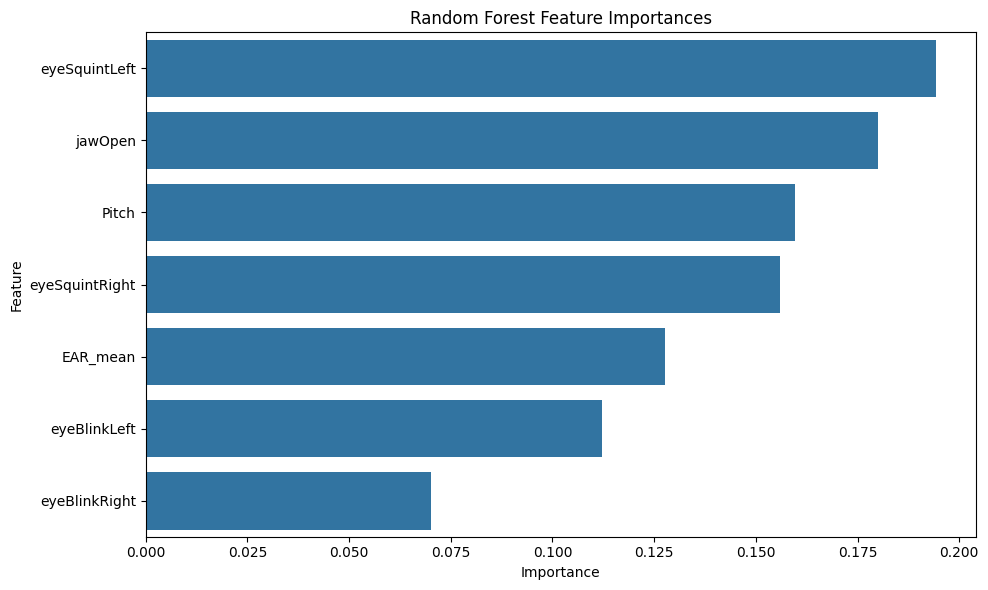

In [45]:
# 4. Evaluate the Model
y_pred = rf_classifier.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy: {overall_accuracy:.4f}")

# Feature Importances
importances = rf_classifier.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Top features for Random Forest):")
print(feature_importance_df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importances')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


Classification Report (Scaled Data):
              precision    recall  f1-score   support

           1       0.97      1.00      0.99        75
           2       0.97      0.90      0.93        68
           3       0.96      0.91      0.93       116
           4       0.97      0.97      0.97       160
           5       0.93      0.99      0.96       165
           6       0.95      0.94      0.95       108

    accuracy                           0.96       692
   macro avg       0.96      0.95      0.96       692
weighted avg       0.96      0.96      0.96       692

Overall Accuracy (Scaled Data): 0.9566

Feature Importances (Top features for Random Forest with Scaled Data):
          Feature  Importance
3   eyeSquintLeft    0.194290
5         jawOpen    0.180050
6           Pitch    0.159612
4  eyeSquintRight    0.155900
2        EAR_mean    0.127721
0    eyeBlinkLeft    0.112217
1   eyeBlinkRight    0.070211


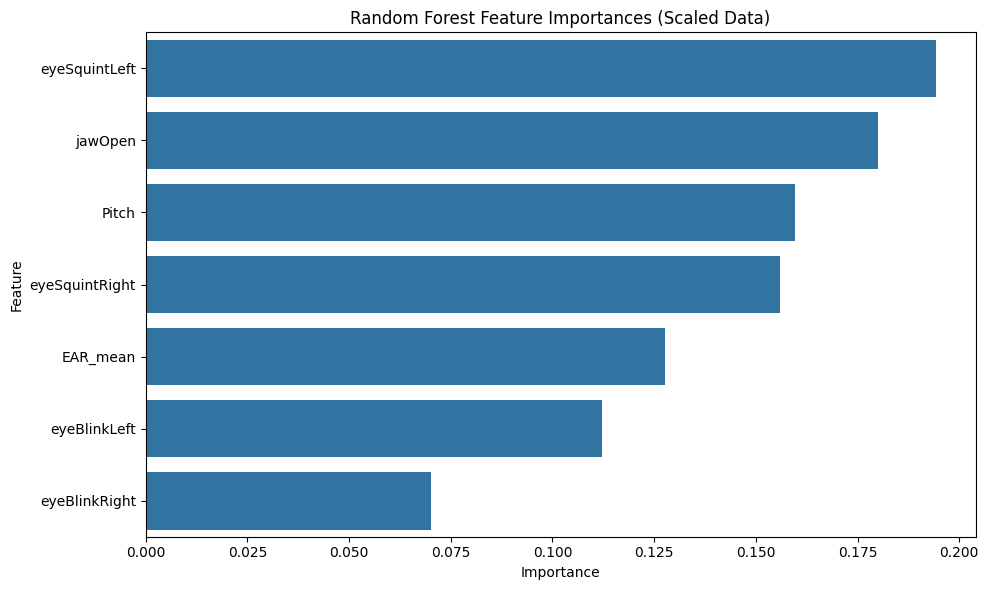

In [46]:
# 4. Evaluate the Model with scaled data
y_pred = rf_classifier.predict(X_test)

print("\nClassification Report (Scaled Data):")
print(classification_report(y_test, y_pred))

overall_accuracy = accuracy_score(y_test, y_pred)
print(f"Overall Accuracy (Scaled Data): {overall_accuracy:.4f}")

# Feature Importances (using original feature names)
importances = rf_classifier.feature_importances_
feature_names = X.columns

feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

print("\nFeature Importances (Top features for Random Forest with Scaled Data):")
print(feature_importance_df)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df)
plt.title('Random Forest Feature Importances (Scaled Data)')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# LSTM Model for Drowsiness Detection

Now that we have successfully built and evaluated a Random Forest model, we will proceed with implementing a Long Short-Term Memory (LSTM) model. LSTMs are particularly well-suited for sequential data, like our video streams, as they can capture temporal dependencies and patterns over time.

This section will cover:
1.  **Data Preparation for LSTM:** Structuring the feature streams into the `(samples, timesteps, features)` format required by LSTMs, including padding and scaling.
2.  **LSTM Model Definition:** Building the neural network architecture using TensorFlow/Keras.
3.  **LSTM Model Training:** Compiling and training the model.
4.  **LSTM Model Evaluation:** Assessing the performance of the LSTM model.

## Data Preparation for LSTM

For the LSTM model, each input sample `X` needs to be a sequence of feature vectors, meaning it must have a 3D shape `(samples, timesteps, features)`. Since our window streams can have varying durations (1 to 6 seconds), we will pad all sequences to a maximum fixed `timesteps` length corresponding to the longest window (6 seconds * 10 FPS = 60 timesteps).

In [47]:
import numpy as np
import pandas as pd
from tqdm.auto import tqdm

# Reload df_meta if not already in scope (though it should be from previous cells)
# metadata_path = os.path.join(processed_folder, "metadata.csv")
# df_meta = pd.read_csv(metadata_path)

# Determine the maximum number of timesteps (max_context_sec * sampling_fps)
max_timesteps = int(max_context_sec * sampling_fps)
num_features = 7 + len(GeometricRatioFeatureLayer.blendshape_names) # 7 geometric + 52 blendshapes

X_lstm = []
y_lstm = []

print(f"Preparing data for LSTM: Padding sequences to {max_timesteps} timesteps with {num_features} features...")

for idx, row in tqdm(df_meta.iterrows(), total=len(df_meta), desc="Loading and padding sequences"):
    # Load the feature array for the current window
    features_array = np.load(row['feature_path'])

    # Pad sequences to max_timesteps. Using 'post' padding with zeros.
    current_timesteps = features_array.shape[0]

    if current_timesteps < max_timesteps:
        # Calculate padding needed
        padding_needed = max_timesteps - current_timesteps
        # Pad with zeros at the end
        padded_features = np.pad(features_array, ((0, padding_needed), (0, 0)), 'constant', constant_values=0)
    else:
        # If for some reason a sequence is longer (shouldn't happen with current logic, but as a safeguard)
        padded_features = features_array[:max_timesteps, :]

    X_lstm.append(padded_features)

    # Labels for LSTM are typically 0-indexed for categorical cross-entropy
    # Original levels are 1-6, so subtract 1 to get 0-5
    y_lstm.append(row['level'] - 1)

# Convert lists to NumPy arrays
X_lstm = np.array(X_lstm, dtype=np.float32)
y_lstm = np.array(y_lstm, dtype=np.int32)

print(f"\nPrepared X_lstm shape: {X_lstm.shape}") # (samples, timesteps, features)
print(f"Prepared y_lstm shape: {y_lstm.shape}") # (samples,)

# Display a sample padded sequence (first sample, first 5 timesteps, first 5 features)
print("\nSample X_lstm (first sample, first 5 timesteps, first 5 features):")
print(X_lstm[0, :5, :5])
print("\nSample y_lstm (first 5 labels):")
print(y_lstm[:5])

Preparing data for LSTM: Padding sequences to 60 timesteps with 58 features...


Loading and padding sequences:   0%|          | 0/3459 [00:00<?, ?it/s]


Prepared X_lstm shape: (3459, 60, 58)
Prepared y_lstm shape: (3459,)

Sample X_lstm (first sample, first 5 timesteps, first 5 features):
[[1.14950217e-01 1.08054139e-01 2.57993373e-03 3.08712816e+00
  2.92060089e+00]
 [1.12726375e-01 1.14522241e-01 2.88917450e-03 3.02508068e+00
  2.70625639e+00]
 [1.17106639e-01 1.15228273e-01 2.63910764e-03 2.95298123e+00
  2.27561212e+00]
 [1.14553675e-01 1.10692687e-01 4.69418941e-03 3.00175309e+00
  1.65425599e+00]
 [1.16684914e-01 1.12452455e-01 3.60255083e-03 3.09478188e+00
  1.33698809e+00]]

Sample y_lstm (first 5 labels):
[4 4 4 4 4]


In [48]:
import joblib
import datetime
from tensorflow.keras.models import load_model

# --- Model Management Configuration ---
# Set to True if you want to ignore existing models and retrain everything
FORCE_RETRAIN = False

# Dynamic naming with versioning (timestamp based)
VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")

# File paths for saving/loading
rf_model_path = os.path.join(models_folder, f"rf_classifier_{VERSION_STR}.joblib")
scaler_path = os.path.join(models_folder, f"feature_scaler_{VERSION_STR}.joblib")
lstm_model_path = os.path.join(models_folder, f"lstm_drowsiness_{VERSION_STR}.keras")

# Helper to find the latest version of a model in the folder
def get_latest_model(folder, prefix, extension):
    files = [f for f in os.listdir(folder) if f.startswith(prefix) and f.endswith(extension)]
    if not files:
        return None
    # Sort by name (which includes timestamp) and get the latest
    return os.path.join(folder, sorted(files)[-1])

print(f"✅ Model management initialized. Force retrain is: {FORCE_RETRAIN}")

✅ Model management initialized. Force retrain is: False


## Splitting and Scaling Data for LSTM

Now, we'll split the prepared `X_lstm` and `y_lstm` into training and testing sets. It's crucial to apply `StandardScaler` to the feature dimension of our 3D data. Since `StandardScaler` expects 2D input, we will reshape our `X_lstm` temporarily for scaling, and then reshape it back to 3D. We will also stratify the split to maintain the distribution of drowsiness levels in both sets.

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data into training and testing sets
# Stratify to ensure equal distribution of classes (drowsiness levels)
X_train_lstm, X_test_lstm, y_train_lstm, y_test_lstm = train_test_split(
    X_lstm, y_lstm, test_size=0.2, random_state=42, stratify=y_lstm
)

print(f"X_train_lstm shape before scaling: {X_train_lstm.shape}")
print(f"X_test_lstm shape before scaling: {X_test_lstm.shape}")

# Initialize StandardScaler
scaler = StandardScaler()

# Reshape X_train_lstm and X_test_lstm from 3D to 2D for scaling
# (samples * timesteps, features)
X_train_reshaped = X_train_lstm.reshape(-1, num_features)
X_test_reshaped = X_test_lstm.reshape(-1, num_features)

# Fit on training data and transform both training and testing data
X_train_scaled_reshaped = scaler.fit_transform(X_train_reshaped)
X_test_scaled_reshaped = scaler.transform(X_test_reshaped)

# Reshape back to 3D: (samples, timesteps, features)
X_train_scaled = X_train_scaled_reshaped.reshape(X_train_lstm.shape)
X_test_scaled = X_test_scaled_reshaped.reshape(X_test_lstm.shape)

print(f"\nSuccessfully split and scaled data for LSTM.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"y_train_lstm shape: {y_train_lstm.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")
print(f"y_test_lstm shape: {y_test_lstm.shape}")

X_train_lstm shape before scaling: (2767, 60, 58)
X_test_lstm shape before scaling: (692, 60, 58)

Successfully split and scaled data for LSTM.
X_train_scaled shape: (2767, 60, 58)
y_train_lstm shape: (2767,)
X_test_scaled shape: (692, 60, 58)
y_test_lstm shape: (692,)


## LSTM Model Definition

We will now define the architecture for our LSTM model. The model will consist of an `Input` layer, one or more `LSTM` layers to capture temporal dependencies, `Dropout` layers for regularization, and a final `Dense` layer with `softmax` activation for multi-class classification (6 drowsiness levels).

In [50]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

# Define the input shape for the LSTM model
# X_train_scaled has shape (samples, timesteps, features)
input_shape = (X_train_scaled.shape[1], X_train_scaled.shape[2]) # (timesteps, features)

# Define the number of classes (drowsiness levels)
num_classes = len(np.unique(y_lstm)) # Should be 6 (0-5 after subtracting 1)

# Build the LSTM model
model = Sequential([
    Input(shape=input_shape),
    LSTM(units=128, return_sequences=True), # Return sequences to stack another LSTM layer
    Dropout(0.3),
    LSTM(units=64), # Last LSTM layer, do not return sequences
    Dropout(0.3),
    Dense(units=num_classes, activation='softmax') # Output layer for 6 classes
])

# Compile the model
# Using sparse_categorical_crossentropy because y_train_lstm is integer-encoded (0-5)
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Display the model summary
model.summary()

print(f"\nLSTM model defined and compiled with input shape {input_shape} and {num_classes} output classes.")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        95,744 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,542 (568.52 KB)

 Trainable params: 145,542 (568.52 KB)

 Non-trainable params: 0 (0.00 B)


LSTM model defined and compiled with input shape (60, 58) and 6 output classes.


## LSTM Model Training

Now we will train the LSTM model using our scaled training data (`X_train_scaled`, `y_train_lstm`) and validate it on the test set (`X_test_scaled`, `y_test_lstm`). We will use `EarlyStopping` to prevent overfitting and a `ModelCheckpoint` to save the best model weights.

In [51]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

latest_lstm = get_latest_model(models_folder, "lstm_drowsiness", ".keras")

if not FORCE_RETRAIN and latest_lstm:
    print(f"📦 Loading existing LSTM model: {latest_lstm}")
    model = load_model(latest_lstm)
else:
    print("🚀 Training new LSTM Model...")

    # Define callbacks
    early_stopping = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
    model_checkpoint = ModelCheckpoint(
        filepath=os.path.join(models_folder, 'best_lstm_model.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    )

    # Train the model
    history = model.fit(
        X_train_scaled, y_train_lstm,
        epochs=50,
        batch_size=32,
        validation_data=(X_test_scaled, y_test_lstm),
        callbacks=[early_stopping, model_checkpoint],
        verbose=1
    )

    # Save the specific versioned copy for tracking
    model.save(lstm_model_path)
    print(f"💾 LSTM model training complete and saved as version: {VERSION_STR}")

📦 Loading existing LSTM model: /content/drive/MyDrive/Argus/models/lstm_drowsiness_20260805_0222.keras


## LSTM Model Evaluation

After training, we will evaluate the performance of our LSTM model on the test set. We'll use a classification report to get detailed metrics like precision, recall, and F1-score for each drowsiness level, and plot the training history.


LSTM Test Loss: 0.0536
LSTM Test Accuracy: 0.9855
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step

Classification Report (LSTM Model):
              precision    recall  f1-score   support

     Level 1       1.00      1.00      1.00        75
     Level 2       0.97      0.96      0.96        68
     Level 3       0.99      0.97      0.98       116
     Level 4       0.98      0.99      0.98       160
     Level 5       0.99      0.99      0.99       165
     Level 6       0.98      0.98      0.98       108

    accuracy                           0.99       692
   macro avg       0.99      0.98      0.98       692
weighted avg       0.99      0.99      0.99       692



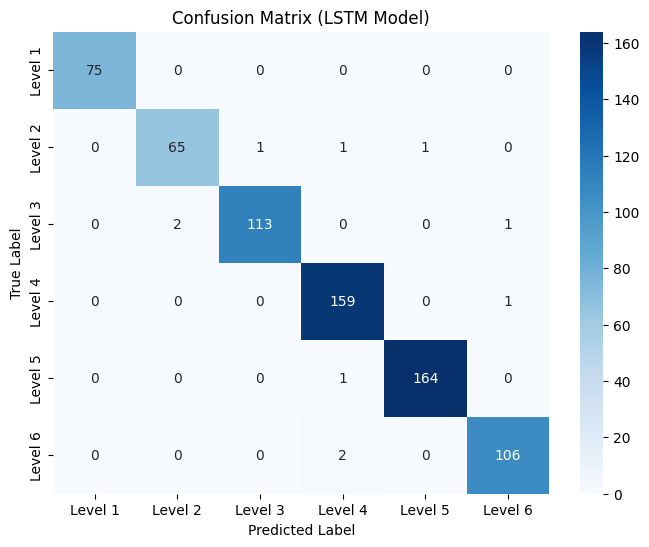


Skipping training history plots: 'history' object not found (model was likely loaded, not trained in this session).


In [52]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test_scaled, y_test_lstm, verbose=0)
print(f"\nLSTM Test Loss: {loss:.4f}")
print(f"LSTM Test Accuracy: {accuracy:.4f}")

# Make predictions on the test set
y_pred_probs = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_probs, axis=1)

# Display classification report
print("\nClassification Report (LSTM Model):")
print(classification_report(y_test_lstm, y_pred, target_names=[f'Level {i+1}' for i in range(num_classes)]))

# Plot Confusion Matrix
conf_matrix = confusion_matrix(y_test_lstm, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Level {i+1}' for i in range(num_classes)],
            yticklabels=[f'Level {i+1}' for i in range(num_classes)])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix (LSTM Model)')
plt.show()

# Plot training history only if it was generated in the current session
# (i.e., if the model was trained, not loaded)
if 'history' in locals() or 'history' in globals():
    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()
else:
    print("\nSkipping training history plots: 'history' object not found (model was likely loaded, not trained in this session).")

## Random Frame Test Summary

This test evaluates the deployed LSTM model's performance on a single, randomly selected frame from one of the video clips. The objective is to see if the model can correctly identify the drowsiness level of this particular frame. If the 'Predicted Drowsiness Level' matches the 'Actual Drowsiness Level', it indicates a successful classification for this instance. This single-frame test provides a quick sanity check of the model's functionality in a real-world scenario.


--- Performing a random test with a guaranteed detected frame ---
Selected video for test: /content/drive/MyDrive/Argus/dataset/raw_videos/subject_04/level_5_clip_01.mp4
Selected frame index (from processed data): 200


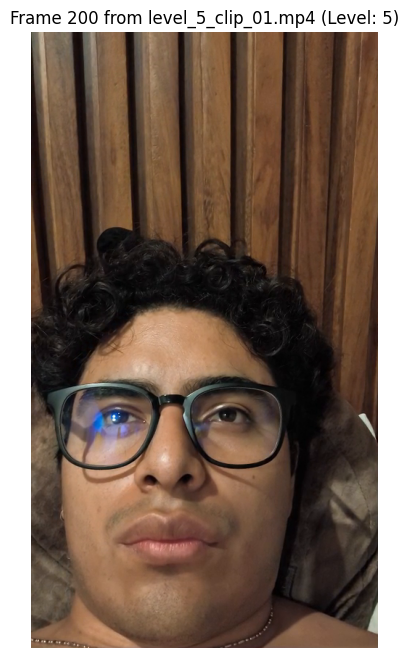

✅ Guaranteed frame with detected face selected and displayed.
✅ Features extracted for the single frame (shape: (58,)).
✅ Data prepared and scaled for LSTM prediction (input shape: (1, 60, 58)).
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step

--- LSTM Model Prediction ---
Predicted Drowsiness Level: 4
Actual Drowsiness Level: 5
❌ Prediction DOES NOT match actual level for this frame.


In [53]:
import numpy as np
import tensorflow as tf
import re
import os
import random
import cv2
import matplotlib.pyplot as plt
import mediapipe as mp
from mediapipe.tasks import python as mp_python
from mediapipe.tasks.python import vision
import pandas as pd

print("\n--- Performing a random test with a guaranteed detected frame ---")

# --- Select a random entry from df_meta which is guaranteed to have a detected face ---
# This assumes df_meta is available and populated from previous steps.
if 'df_meta' not in locals() and 'df_meta' not in globals():
    raise ValueError("df_meta DataFrame not found. Please ensure the dataset processing pipeline has been run.")

if df_meta.empty:
    raise ValueError("df_meta is empty. No processed features available to pick a valid frame from.")

# Randomly select one row from the metadata DataFrame
selected_meta_row = df_meta.sample(n=1).iloc[0]

selected_video_path = selected_meta_row['parent_video']
# Extract the start frame index from the feature_path filename
# Example: 'subject_01_level_5_clip_01_w1.0s_start0.npy'
feature_filename = os.path.basename(selected_meta_row['feature_path'])
match_start = re.search(r'start(\d+)\.npy', feature_filename)
if match_start:
    random_frame_idx = int(match_start.group(1)) # This is the start frame of the window
else:
    # Fallback if parsing fails, but feature_path format should be consistent
    random_frame_idx = 0
    print(f"Warning: Could not parse start frame from {feature_filename}. Using frame 0.")

# Construct the full path to the selected video
# The original path construction was incorrect, pointing to a 'features' subfolder under raw_videos.
# It should point to the subject's folder under raw_videos.
full_selected_video_path = os.path.join(raw_videos_folder, selected_meta_row['subject'], selected_video_path)

print(f"Selected video for test: {full_selected_video_path}")
print(f"Selected frame index (from processed data): {random_frame_idx}")

# Open the video file
cap = cv2.VideoCapture(full_selected_video_path)
if not cap.isOpened():
    raise IOError(f"Cannot open video file: {full_selected_video_path}")

# Get total frame count
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
if frame_count == 0:
    raise ValueError(f"Video file {full_selected_video_path} has no frames.")

# Select a random frame index
# The random_frame_idx is already determined from feature_filename parsing, but ensuring it's within bounds.
# For consistency, we use the extracted start frame from the NPY file for the test.

# Set the video capture to the random frame
cap.set(cv2.CAP_PROP_POS_FRAMES, random_frame_idx)

# Read the frame
ret, bgr_frame = cap.read()
# Get FPS here, before releasing cap, for timestamp calculation
src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
cap.release()

if not ret:
    raise Exception(f"Failed to read frame {random_frame_idx} from {full_selected_video_path}")

# Display the raw selected frame
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)) # Convert BGR to RGB for matplotlib
plt.title(f"Frame {random_frame_idx} from {os.path.basename(selected_video_path)} (Level: {selected_meta_row['level']})")
plt.axis('off')
plt.show()

print("✅ Guaranteed frame with detected face selected and displayed.")

# --- Face detection and processing for the selected frame (now guaranteed) ---
# Convert the OpenCV BGR frame to RGB and then to a MediaPipe Image object
rgb_frame = cv2.cvtColor(bgr_frame, cv2.COLOR_BGR2RGB)
mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=rgb_frame)

# Create a detector for this specific test, using VIDEO running mode for consistency
# with the FeatureExtractionPipeline which generated df_meta
test_detector = vision.FaceLandmarker.create_from_options(face_landmarker_options)

# Perform face landmark detection using detect_for_video and a timestamp
timestamp_ms = int(random_frame_idx * (1000.0 / src_fps))
detection_result = test_detector.detect_for_video(mp_image, timestamp_ms)

# Close the detector created for this test
test_detector.close()

# The following 'else' branch for detection_result.face_landmarks should theoretically not be hit
# since we picked a frame that was successfully processed. If it is hit, it indicates a discrepancy.
if not detection_result.face_landmarks:
    print("⚠️ Discrepancy: No face detected in this frame, even though it came from processed data. Proceeding with dummy values.")
    # In a real scenario, this would likely trigger an error or a more robust fallback
    lm = [] # Empty landmarks to prevent errors later
    R = np.eye(3, dtype=np.float32) # Changed tf.float32 to np.float32
    bs_dict = {}
else:
    lm = detection_result.face_landmarks[0]
    # Extract landmarks and rotation matrix from the detection result
    landmarks_xy = tf.constant([[p.x, p.y] for p in lm], dtype=tf.float32)
    R = np.array(detection_result.facial_transformation_matrixes[0])[:3, :3] if detection_result.facial_transformation_matrixes else np.eye(3, dtype=np.float32)
    R_tf = tf.constant(R, dtype=tf.float32)

    # Calculate geometric ratios using the defined layer
    ratios = ratio_layer(landmarks_xy[tf.newaxis, ...], R_tf[tf.newaxis, ...]).numpy()[0] # Shape (7,)

    # Extract blendshape scores in the correct order using the global blendshape names
    bs_dict = {b.category_name: b.score for b in detection_result.face_blendshapes[0]} if detection_result.face_blendshapes else {}

bs_scores = [bs_dict.get(name, 0.0) for name in GeometricRatioFeatureLayer.blendshape_names] # Shape (52,)

# Combine geometric ratios and blendshapes into a single feature vector
single_frame_features = np.concatenate([ratios, bs_scores]).astype(np.float32) # Shape (59,)

print(f"✅ Features extracted for the single frame (shape: {single_frame_features.shape}).")

# Prepare for LSTM: The LSTM expects (batch_size, timesteps, features)
# We need to pad the single frame's features to the maximum sequence length (max_timesteps)
lstm_input_padded = np.zeros((1, max_timesteps, num_features), dtype=np.float32)
# Place the single frame data at the first timestep
lstm_input_padded[0, 0, :] = single_frame_features

# Scale the input using the previously fitted scaler
# Reshape for scaler: (1 * max_timesteps, num_features)
lstm_input_reshaped = lstm_input_padded.reshape(-1, num_features)
lstm_input_scaled_reshaped = scaler.transform(lstm_input_reshaped)
# Reshape back to (1, max_timesteps, num_features)
lstm_input_scaled = lstm_input_scaled_reshaped.reshape(1, max_timesteps, num_features)

print(f"✅ Data prepared and scaled for LSTM prediction (input shape: {lstm_input_scaled.shape}).")

# Make prediction with the trained LSTM model
predictions = model.predict(lstm_input_scaled)
# The output is a probability distribution; get the class with the highest probability
predicted_level = np.argmax(predictions, axis=1)[0] + 1 # Add 1 to convert from 0-indexed to 1-6 level

# Extract the actual level from the selected_meta_row
actual_level = selected_meta_row['level']

print(f"\n--- LSTM Model Prediction ---")
print(f"Predicted Drowsiness Level: {predicted_level}")
print(f"Actual Drowsiness Level: {actual_level}")

if predicted_level == actual_level:
    print("✅ Prediction matches actual level for this frame!")
else:
    print("❌ Prediction DOES NOT match actual level for this frame.")

## Geometric rate feature layer + LSTM Model for Deployment

To create a deployable model that takes raw MediaPipe outputs and directly provides drowsiness predictions, we need to wrap our feature extraction, normalization, and LSTM prediction logic into a single Keras model. This ensures that the entire inference pipeline is self-contained and can be saved as a single `.keras` file for efficient deployment.

### Overview of the Geometric rate feature layer + LSTM Pipeline:
1.  **Input**: Raw MediaPipe outputs (facial landmarks, rotation matrix, blendshape scores).
2.  **Geometric Feature Extraction**: A custom `GeometricRatioFeatureLayer` computes EAR, MAR, and head pose from landmarks and the rotation matrix.
3.  **Feature Combination**: Geometric features are concatenated with raw blendshape scores.
4.  **Sequence Accumulation & Padding**: Single-frame features are collected and padded to a fixed `max_timesteps` length.
5.  **Normalization**: A `tf.keras.layers.Normalization` layer standardizes the features using statistics learned during training.
6.  **LSTM Prediction**: The normalized sequence is fed into the pre-trained LSTM model for drowsiness classification.
7.  **Output**: Drowsiness level prediction.

In [54]:
import joblib
import tensorflow as tf

# Ensure the scaler object is loaded and num_features are defined
# (These should be available from previous cells, but we check for robustness)
if 'scaler' not in globals():
    latest_scaler_path = get_latest_model(models_folder, "feature_scaler", ".joblib")
    if latest_scaler_path:
        print(f"Loading scaler from {latest_scaler_path}")
        scaler = joblib.load(latest_scaler_path)
    else:
        raise FileNotFoundError("No scaler found. Please train the Random Forest model first.")

if 'num_features' not in globals():
    # Fallback if num_features wasn't explicitly defined earlier (should be 59)
    num_features = 7 + len(GeometricRatioFeatureLayer.blendshape_names)

# Create a Keras Normalization layer and set its mean and variance from the trained StandardScaler
norm_layer = tf.keras.layers.Normalization(axis=-1) # Normalize per feature

# Explicitly build the layer with the expected input shape
# The input to normalization_layer in LstmGeometricFeatureModel.call is `sequence_input`
# which has shape (batch, max_timesteps, features)
norm_layer.build(input_shape=(None, None, num_features))

norm_layer.set_weights([scaler.mean_, scaler.var_, tf.constant(1.0, dtype=tf.float32)])

print(f"✅ Keras Normalization layer initialized with {num_features} features.")

✅ Keras Normalization layer initialized with 58 features.


### LstmGeometricFeatureModel Class

This custom Keras `Model` subclass encapsulates the entire prediction pipeline from raw MediaPipe outputs to drowsiness levels. It integrates:

*   **Input**: Raw facial landmarks (`(batch, 478, 2)`), rotation matrix (`(batch, 3, 3)`), and blendshape scores (`(batch, 52)`).
*   **`GeometricRatioFeatureLayer`**: Computes EAR, MAR, Pitch, Yaw, Roll, and validity from landmarks and rotation.
*   **Concatenation**: Combines geometric features with blendshape scores.
*   **Sequence Accumulation & Padding**: This model is designed for real-time inference, where frames arrive one by one. It accumulates `max_timesteps` worth of single-frame features, padding the sequence if fewer than `max_timesteps` are available. This is crucial for feeding a fixed-size sequence to the LSTM.
*   **`Normalization` Layer**: Applies the pre-trained feature scaling.
*   **Pre-trained LSTM Model**: The core prediction model.

This structure ensures that the deployed model handles all necessary preprocessing internally.

In [55]:
import tensorflow as tf

class LstmGeometricFeatureModel(tf.keras.Model):
    def __init__(self, ratio_layer: GeometricRatioFeatureLayer,
                 normalization_layer: tf.keras.layers.Normalization,
                 lstm_model: tf.keras.Model,
                 max_timesteps: int = 60,
                 num_features: int = 59, **kwargs):
        super().__init__(**kwargs)
        self.ratio_layer = ratio_layer
        self.normalization_layer = normalization_layer
        self.lstm_model = lstm_model
        self.max_timesteps = max_timesteps
        self.num_features = num_features

        # Initialize a buffer for the sequence history (for real-time inference)
        # Note: This buffer is stateful, so it's handled within the model for deployment.
        self.feature_buffer = tf.Variable(
            tf.zeros([1, self.max_timesteps, self.num_features], dtype=tf.float32),
            trainable=False, # This buffer is not part of model training
            name="feature_buffer"
        )

        # Ensure blendshape names are available to the ratio_layer for consistent ordering
        if not hasattr(self.ratio_layer, 'blendshape_names'):
            raise AttributeError("ratio_layer must have 'blendshape_names' attribute defined.")

    def call(self, inputs, training=False):
        # inputs is a dictionary: {'landmarks': (1, 478, 2), 'rotation_matrix': (1, 3, 3), 'blendshapes': (1, 52)}
        landmarks = inputs['landmarks']
        rotation_matrix = inputs['rotation_matrix']
        raw_blendshapes = inputs['blendshapes']

        # 1. Geometric Feature Extraction
        geometric_features = self.ratio_layer(landmarks, rotation_matrix)

        # 2. Combine Geometric Features and Blendshapes
        # Ensure raw_blendshapes matches the expected order if necessary, but here we assume it's ordered.
        combined_features = tf.concat([geometric_features, raw_blendshapes], axis=-1)

        # Reshape to (1, 1, num_features) to represent a single frame's features
        single_frame_features = tf.reshape(combined_features, [1, 1, self.num_features])

        # 3. Update the feature buffer (sliding window)
        # Shift old features to the left, insert new feature at the right
        updated_buffer = tf.concat(
            [self.feature_buffer[:, 1:, :], single_frame_features],
            axis=1
        )
        self.feature_buffer.assign(updated_buffer)

        # Use the current state of the buffer as the sequence input for the LSTM
        sequence_input = self.feature_buffer

        # 4. Normalization
        normalized_sequence = self.normalization_layer(sequence_input)

        # 5. LSTM Prediction
        predictions = self.lstm_model(normalized_sequence, training=training)

        return predictions

    def get_config(self):
        config = super().get_config()
        config.update({
            "ratio_layer": tf.keras.utils.serialize_keras_object(self.ratio_layer),
            "normalization_layer": tf.keras.utils.serialize_keras_object(self.normalization_layer),
            "lstm_model": tf.keras.utils.serialize_keras_object(self.lstm_model),
            "max_timesteps": self.max_timesteps,
            "num_features": self.num_features,
        })
        return config

    @classmethod
    def from_config(cls, config):
        # Deserialize nested Keras objects
        ratio_layer_config = config.pop("ratio_layer")
        normalization_layer_config = config.pop("normalization_layer")
        lstm_model_config = config.pop("lstm_model")

        # Provide custom_objects for custom layers during deserialization
        ratio_layer = tf.keras.utils.deserialize_keras_object(ratio_layer_config, custom_objects={'GeometricRatioFeatureLayer': GeometricRatioFeatureLayer})
        normalization_layer = tf.keras.utils.deserialize_keras_object(normalization_layer_config)
        lstm_model = tf.keras.utils.deserialize_keras_object(lstm_model_config)

        # Instantiate the class with the deserialized objects and remaining config
        return cls(ratio_layer=ratio_layer,
                   normalization_layer=normalization_layer,
                   lstm_model=lstm_model,
                   **config)

print("✅ LstmGeometricFeatureModel class defined.")

✅ LstmGeometricFeatureModel class defined.


### Instantiating and Building the Geometric rate feature layer + LSTM Model

Now we instantiate our `LstmGeometricFeatureModel` by providing it with the `GeometricRatioFeatureLayer`, the Keras `Normalization` layer, and the trained LSTM model. Crucially, we build the model by calling it with dummy inputs. This step is necessary for Keras `Model` subclasses to trace and create their internal graph, making the model ready for summary display and saving.

We also ensure all necessary components (`model`, `ratio_layer`, `scaler`, `max_timesteps`, `num_features`, `pose_validity_threshold_deg`) are available in the environment from previous cells.

In [56]:
import joblib
import tensorflow as tf

# Ensure required components are loaded/defined
if 'model' not in globals():
    latest_lstm_path = get_latest_model(models_folder, "lstm_drowsiness", ".keras")
    if latest_lstm_path:
        print(f"Loading LSTM model from {latest_lstm_path}")
        model = tf.keras.models.load_model(latest_lstm_path)
    else:
        raise FileNotFoundError("No LSTM model found. Please train the LSTM model first.")

if 'ratio_layer' not in globals():
    if 'pose_validity_threshold_deg' not in globals():
        pose_validity_threshold_deg = 20.0 # Default value if not defined
        print(f"Using default pose_validity_threshold_deg: {pose_validity_threshold_deg}")
    ratio_layer = GeometricRatioFeatureLayer(pose_validity_threshold_deg=pose_validity_threshold_deg)

if 'norm_layer' not in globals():
    # This should have been created in a preceding cell, but as a fallback:
    if 'scaler' not in globals():
        latest_scaler_path = get_latest_model(models_folder, "feature_scaler", ".joblib")
        if latest_scaler_path:
            scaler = joblib.load(latest_scaler_path)
        else:
            raise FileNotFoundError("Scaler not found. Ensure it's loaded or created.")
    if 'num_features' not in globals():
        num_features = 7 + len(GeometricRatioFeatureLayer.blendshape_names)
    norm_layer = tf.keras.layers.Normalization(axis=-1)
    norm_layer.set_weights([scaler.mean_, scaler.var_])

# Instantiate the LstmGeometricFeatureModel
lstm_geometric_feature_model = LstmGeometricFeatureModel(
    ratio_layer=ratio_layer,
    normalization_layer=norm_layer,
    lstm_model=model,
    max_timesteps=max_timesteps,
    num_features=num_features
)

# Build the model by calling it with dummy inputs
# The input to the LstmGeometricFeatureModel call method is a dictionary of Tensors.
# These shapes should be for a single frame (batch size 1).
example_landmarks = tf.zeros([1, 478, 2], dtype=tf.float32)
example_rotation_matrix = tf.eye(3, batch_shape=[1], dtype=tf.float32)
example_blendshapes = tf.zeros([1, len(GeometricRatioFeatureLayer.blendshape_names)], dtype=tf.float32)

dummy_inputs = {
    'landmarks': example_landmarks,
    'rotation_matrix': example_rotation_matrix,
    'blendshapes': example_blendshapes
}

# Call the model with dummy inputs to build its graph
_ = lstm_geometric_feature_model(dummy_inputs)

print("\n✅ Geometric rate feature layer + LSTM Keras Model instantiated and built.")
lstm_geometric_feature_model.summary()


✅ Geometric rate feature layer + LSTM Keras Model instantiated and built.


Model: "lstm_geometric_feature_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ geometric_ratio_feature_layer   │ ?                      │             0 │
│ (GeometricRatioFeatureLayer)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, None, 58)       │           117 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │       145,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,659 (568.98 KB)

 Trainable params: 145,542 (568.52 KB)

 Non-trainable params: 117 (472.00 B)

### Saving the Geometric rate feature layer + LSTM Model

To ensure our complete drowsiness detection system can be deployed easily, we save the `lstm_geometric_feature_model` in the Keras native format. This format preserves the entire model architecture, including custom layers, learned weights, the normalization parameters, and the internal state (`feature_buffer`), allowing for seamless loading and inference in a production environment.

The model will be saved to our `models_folder` with a version string for tracking.

In [57]:
import os
import tensorflow as tf

# Ensure VERSION_STR and models_folder are available from previous cells
if 'VERSION_STR' not in globals():
    import datetime
    VERSION_STR = datetime.datetime.now().strftime("%Y%m%d_%H%M")
    print(f"Generated VERSION_STR: {VERSION_STR}")

if 'models_folder' not in globals():
    raise NameError("models_folder is not defined. Ensure project setup cells are run.")

# Define the path for the end-to-end model with the new name
end_to_end_model_path = os.path.join(models_folder, f"lstm_geometric_feature_model_{VERSION_STR}.keras")

# Save the end-to-end model
lstm_geometric_feature_model.save(end_to_end_model_path)

print(f"✅ Geometric rate feature layer + LSTM Model saved successfully to: {end_to_end_model_path}")

✅ Geometric rate feature layer + LSTM Model saved successfully to: /content/drive/MyDrive/Argus/models/lstm_geometric_feature_model_20260811_0444.keras


In [58]:
import tensorflow as tf
import os

# Ensure `end_to_end_model_path` is correctly defined (it should be from the saving cell)
if 'end_to_end_model_path' not in globals():
    # Fallback to reconstruct the path if the variable is not in scope
    if 'models_folder' in globals() and 'VERSION_STR' in globals():
        end_to_end_model_path = os.path.join(models_folder, f"lstm_geometric_feature_model_{VERSION_STR}.keras")
    else:
        raise NameError("Could not determine `end_to_end_model_path`. Please ensure previous cells were run.")


# Load the saved model
# We need to provide custom_objects if LstmGeometricFeatureModel or GeometricRatioFeatureLayer are custom Keras classes
# This is done by passing a dictionary to the custom_objects argument of load_model
loaded_model = tf.keras.models.load_model(
    end_to_end_model_path,
    custom_objects={'LstmGeometricFeatureModel': LstmGeometricFeatureModel,
                    'GeometricRatioFeatureLayer': GeometricRatioFeatureLayer}
)

print(f"✅ Model loaded successfully from: {end_to_end_model_path}")
print(f"Type of loaded model: {type(loaded_model)}")

# Optionally, you can also print a summary of the loaded model to verify its structure
loaded_model.summary()

✅ Model loaded successfully from: /content/drive/MyDrive/Argus/models/lstm_geometric_feature_model_20260811_0444.keras
Type of loaded model: <class '__main__.LstmGeometricFeatureModel'>


Model: "lstm_geometric_feature_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ geometric_ratio_feature_layer   │ ?                      │             0 │
│ (GeometricRatioFeatureLayer)    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ normalization (Normalization)   │ (None, None, 58)       │           117 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 6)              │       145,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 145,659 (568.98 KB)

 Trainable params: 145,542 (568.52 KB)

 Non-trainable params: 117 (472.00 B)

## End-to-End Live Stream Simulation

This simulation bridges the gap between raw video and inference. It bypasses the `.npy` files and performs the entire pipeline in sequence:
**Raw Video Frame → MediaPipe Detection → `LstmGeometricFeatureModel` → Prediction.**

In [60]:
import cv2
import numpy as np
import tensorflow as tf
import random
import os
from mediapipe.tasks.python import vision
import mediapipe as mp

# 1. Select a random video from the original dataset
random_video_path = random.choice(video_files)
subject_id = os.path.basename(os.path.dirname(random_video_path))
filename = os.path.basename(random_video_path)

# Extract ground truth level from filename
match = re.search(r'level_(\d+)', filename, re.IGNORECASE)
actual_level = int(match.group(1)) if match else "Unknown"

print(f"--- Live Simulation Starting ---")
print(f"Target Video: {filename} (Subject: {subject_id})")
print(f"Ground Truth Label: {actual_level}\n")

# 2. Setup Video Capture and Local Detector
cap = cv2.VideoCapture(random_video_path)
src_fps = cap.get(cv2.CAP_PROP_FPS) or 30.0
frame_stride = max(1, round(src_fps / sampling_fps))

# Initialize a fresh detector for this video to reset MediaPipe's internal clock
local_detector = vision.FaceLandmarker.create_from_options(face_landmarker_options)

# 3. Stream frames at 10 FPS
frame_count = 0
processed_count = 0
max_sim_frames = 60 # Simulate up to 6 seconds of data

print(f"Processing frames at {sampling_fps} FPS...")

while processed_count < max_sim_frames:
    ret, frame_bgr = cap.read()
    if not ret: break

    if frame_count % frame_stride == 0:
        # Prepare MediaPipe Image
        frame_rgb = cv2.cvtColor(frame_bgr, cv2.COLOR_BGR2RGB)
        mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=frame_rgb)
        timestamp_ms = int(frame_count * (1000.0 / src_fps))

        # Run MediaPipe
        result = local_detector.detect_for_video(mp_image, timestamp_ms)

        if result.face_landmarks:
            # Extract raw components needed by the model dictionary
            lm = result.face_landmarks[0]
            landmarks_xy = tf.constant([[p.x, p.y] for p in lm], dtype=tf.float32)[tf.newaxis, ...]

            R = np.array(result.facial_transformation_matrixes[0])[:3, :3] if result.facial_transformation_matrixes else np.eye(3, dtype=np.float32)
            R_tf = tf.constant(R, dtype=tf.float32)[tf.newaxis, ...]

            bs_dict = {b.category_name: b.score for b in result.face_blendshapes[0]} if result.face_blendshapes else {}
            bs_scores = tf.constant([[bs_dict.get(name, 0.0) for name in GeometricRatioFeatureLayer.blendshape_names]], dtype=tf.float32)

            # Create input dictionary
            model_inputs = {
                'landmarks': landmarks_xy,
                'rotation_matrix': R_tf,
                'blendshapes': bs_scores
            }

            # Feed into the assembled model
            # This updates the internal buffer and produces a prediction
            probs = loaded_model(model_inputs, training=False)
            processed_count += 1
        else:
            # Optional: handle 'face lost' in a real app (e.g., reset buffer)
            pass

    frame_count += 1

cap.release()
local_detector.close()

# 4. Final Assessment
final_probs = probs.numpy()
predicted_idx = np.argmax(final_probs, axis=1)[0]
predicted_level = predicted_idx + 1
confidence = final_probs[0][predicted_idx]

print(f"\n--- Simulation Results ---")
print(f"Final Predicted Level: {predicted_level}")
print(f"Actual Ground Truth: {actual_level}")
print(f"Confidence: {confidence:.2%}")

if predicted_level == actual_level:
    print("\u2705 SUCCESS: The model correctly identified the level from raw video stream!")
else:
    print("\u274c MISMATCH: The model output differs from the ground truth.")

--- Live Simulation Starting ---
Target Video: level_3_clip_02.mp4 (Subject: subject_02)
Ground Truth Label: 3

Processing frames at 10 FPS...

--- Simulation Results ---
Final Predicted Level: 3
Actual Ground Truth: 3
Confidence: 99.88%
✅ SUCCESS: The model correctly identified the level from raw video stream!
